In [1]:
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm

from matplotlib import ticker
import matplotlib.colors as colors
from matplotlib.ticker import LogFormatterSciNotation, LogFormatter, FixedFormatter

from pathlib import Path

import seaborn as sns

import pickle

import pandas as pd

import h5py

try:
    plt.style.use(['presentation'])
except:
    print('MPL style not found')

plt.rcParams.update({'font.size': 16})

MPL style not found


In [2]:
#################################
# Folder path to be modified

folder_name = [
    # Broader parameter scan in Qp and fine offset scan
    '2025-05-04_rcschain_5tev_xsuite_pyht_scan_beam_properties_fine_offset_scan_cavity_PyHT_wake_table_TESLA_2025',

]

simulation_folder_path = Path('/home/damorim/cernbox/muc_htcondor/') / Path(folder_name[0])

plot_save_location = (simulation_folder_path / 'results_plots/')
plot_save_location.mkdir(parents=True, exist_ok=True)
#################################

In [3]:
#################################
# Simulation scans to be modified
# This one includes more scans (number of macroparticles, number of wakefield slices...)

# # 2025-05-04_rcschain_5tev_xsuite_pyht_scan_beam_properties_fine_offset_scan_cavity_PyHT_wake_table_TESLA_2025
scaling_factor_scan = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
chroma_scan = [-40, -30, -20, -10, -5, -2, 0, 2, 5, 10, 20, 30, 40]
damper_scan = [4, 10, 50, np.inf]
offset_scan = [0.0, 10.0e-6, 50.0e-6, 100.0e-6, 250.e-6, 500.0e-6, 750.0e-6, 1e-3]
nturns_wake_scan = [1, 5,]
nMP_scan = [int(1e6),]
nsliceswake_scan = [2000,]

number_of_rcs = 4

last_rcs_to_plot = 'RCS4'
n_turns_last_rcs = 55

# last_rcs_to_plot = 'RCS3'
# n_turns_last_rcs = 66

#################################

list_of_dataframes = []
list_of_missing_simulations = []

for ii_scaling_value, scaling_value in enumerate(scaling_factor_scan):
    for ii_chroma_value, chroma_value in enumerate(chroma_scan):
        for ii_damper_value, damper_value in enumerate(damper_scan):
            for ii_offset_value, offset_value in enumerate(offset_scan):
                for ii_nturnswake_value, nturnswake_value in enumerate(nturns_wake_scan):
                    for ii_nMP_value, nMP_value in enumerate(nMP_scan):
                        for ii_nsliceswake_value, nsliceswake_value in enumerate(nsliceswake_scan):

                            individual_simulation_folder = f'scaling_{scaling_value}_chroma_{chroma_value}_damper_{damper_value}_offset_{offset_value}_nturnswake_{nturnswake_value}_nMP_{nMP_value}_nsliceswake_{nsliceswake_value}'
                            full_simulation_path = simulation_folder_path / Path(individual_simulation_folder)

                            # transverse_data_pickle_file = list(full_simulation_path.glob('**/transverse_data.pkl'))
                            emittance_data_pickle_file = list(full_simulation_path.glob('**/rcs_results.pkl'))
                            # rcs_parameters_pickle_file = list(full_simulation_path.glob('**/rcs_parameters.pkl'))

                            # Check that we find a pickle file (and only one). If so we open and load its data.
                            # Otherwise we add the simulation name to the missing list
                            if len(emittance_data_pickle_file) != 1:
                                list_of_missing_simulations.append(individual_simulation_folder)
                            else:
                                emittance_data = pd.read_pickle(emittance_data_pickle_file[0])
                                
                                # Some newer sim files have a different structure
                                for key in emittance_data.keys():
                                    if 'number_of_rf_stations' in emittance_data[key]:
                                        emittance_data[key].pop('number_of_rf_stations', None)


                                # from https://datascientyst.com/add-level-index-pandas-dataframe/
                                df = pd.DataFrame.from_dict({(i,j): emittance_data[i][j] 
                                                            for i in emittance_data.keys() 
                                                            for j in emittance_data[i].keys()},
                                                            orient='index')

                                number_of_rows = number_of_rcs * 3  # Number of RCS * number of coordinates (x/y/z in this case)

                                # Add columns to the DF index
                                df.index = pd.MultiIndex.from_tuples(df.index).rename("RCS", level=0).rename("coord", level=1)

                                old_idx = df.index.to_frame()
                                old_idx.insert(0, 'nsliceswake', [nsliceswake_value]*number_of_rows)
                                old_idx.insert(0, 'nMP', [nMP_value]*number_of_rows)
                                old_idx.insert(0, 'nturnswake', [nturnswake_value]*number_of_rows)
                                old_idx.insert(0, 'offset', [float(offset_value)]*number_of_rows)
                                old_idx.insert(0, 'damper', [damper_value]*number_of_rows)
                                old_idx.insert(0, 'chroma', [chroma_value]*number_of_rows)
                                old_idx.insert(0, 'scaling', [scaling_value]*number_of_rows)

                                df.index = pd.MultiIndex.from_frame(old_idx)

                                list_of_dataframes.append(df)


simulation_run_data_df = pd.concat(list_of_dataframes)

## Exploration of the simulation run data

In [4]:
# First we reset the index to have a flat dataframe, then we can use the columns to filter and plot the data
expanded_df = simulation_run_data_df.reset_index()

# Rename the last 66 columns that have a numeric index to turn_{numeric_index}
columns_to_replace = np.arange(66)
expanded_df.rename(columns=dict(zip(columns_to_replace, [f'turn_{i}' for i in columns_to_replace])), inplace=True)

# Describe all columns in the dataframe, including non-numeric ones
expanded_df.describe(include='all')

/home/damorim/WorkDrive/Trainings/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,scaling,chroma,damper,offset,nturnswake,nMP,nsliceswake,RCS,coord,turn_0,...,turn_56,turn_57,turn_58,turn_59,turn_60,turn_61,turn_62,turn_63,turn_64,turn_65
count,69324.000000,69324.000000,69324.0,69324.000000,69324.000000,69324.0,69324.0,69324,69324,6.932400e+04,...,1.733100e+04,1.733100e+04,1.733100e+04,1.733100e+04,1.733100e+04,1.733100e+04,1.733100e+04,1.733100e+04,1.733100e+04,1.733100e+04
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RCS1,emittance_x,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17331,23108,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.633235,-0.006232,inf,0.000332,3.005885,1000000.0,2000.0,NaN,NaN,2.189430e+06,...,2.202380e+06,2.207776e+06,2.214615e+06,2.214580e+06,2.203568e+06,2.200861e+06,2.206226e+06,2.211728e+06,2.211598e+06,2.201752e+06
std,3.382130,21.575870,NaN,0.000354,2.000006,0.0,0.0,NaN,NaN,3.220542e+06,...,3.315692e+06,3.322741e+06,3.331484e+06,3.332588e+06,3.318224e+06,3.315877e+06,3.322874e+06,3.329757e+06,3.330827e+06,3.318418e+06
min,0.000000,-40.000000,4.0,0.000000,1.000000,1000000.0,2000.0,NaN,NaN,2.478084e-05,...,2.487654e-05,2.487489e-05,2.487932e-05,2.487691e-05,2.487468e-05,2.487660e-05,2.487528e-05,2.487963e-05,2.487656e-05,2.487454e-05
25%,0.100000,-10.000000,10.0,0.000010,1.000000,1000000.0,2000.0,NaN,NaN,2.502161e-05,...,2.503545e-05,2.503564e-05,2.503565e-05,2.503592e-05,2.503622e-05,2.503642e-05,2.503669e-05,2.503689e-05,2.503723e-05,2.503738e-05
50%,1.000000,0.000000,10.0,0.000250,5.000000,1000000.0,2000.0,NaN,NaN,3.882990e-05,...,1.121583e-04,1.112662e-04,1.088360e-04,1.157268e-04,1.170732e-04,1.168893e-04,1.179092e-04,1.149162e-04,1.223287e-04,1.228630e-04
75%,5.000000,10.000000,50.0,0.000500,5.000000,1000000.0,2000.0,NaN,NaN,6.579477e+06,...,7.228068e+06,7.247436e+06,7.277137e+06,7.281167e+06,7.239830e+06,7.228778e+06,7.248475e+06,7.273915e+06,7.277710e+06,7.241866e+06


The dataframe gives the turn by turn emittance in each RCS, but we will focus on the final emittance in each RCS. For this we will create new columns with the final emittance in each RCS, and then we will use these columns to create a regression model.

In [5]:
# Loop through the three emittance coordinates (x, y, z) and create new columns with the final emittance in each RCS

for coord in ['emittance_x', 'emittance_y', 'emittance_z']:
    for rcs in ['RCS1', 'RCS2', 'RCS3', 'RCS4']:
        
        # Select the rows corresponding to the current RCS and coordinate
        emittance_data = expanded_df.loc[expanded_df['RCS'] == rcs].loc[expanded_df['coord'] == coord]
        
        # The last turn for the selected RCS is in the last column turn_{} that doesn't have NaN values.
        last_turn_emittance_values = emittance_data.filter(like='turn_').dropna(axis=1).iloc[:, -1]
        
        # Create a new column with the final emittance in each RCS and coordinate
        expanded_df[f'final_emittance_{rcs}_{coord}'] = last_turn_emittance_values

In [6]:
# Drop the columns that have the turn by turn emittance values, since we are only interested in the final emittance values
columns_to_drop = [col for col in expanded_df.columns if col.startswith('turn_')]
expanded_df = expanded_df.drop(columns=columns_to_drop)

In [7]:
expanded_df.head(12)

,scaling,chroma,damper,offset,nturnswake,nMP,nsliceswake,RCS,coord,final_emittance_RCS1_emittance_x,...,final_emittance_RCS3_emittance_x,final_emittance_RCS4_emittance_x,final_emittance_RCS1_emittance_y,final_emittance_RCS2_emittance_y,final_emittance_RCS3_emittance_y,final_emittance_RCS4_emittance_y,final_emittance_RCS1_emittance_z,final_emittance_RCS2_emittance_z,final_emittance_RCS3_emittance_z,final_emittance_RCS4_emittance_z
0,0.0,-40,4.0,0.0,1,1000000,2000,RCS1,emittance_x,0.000025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,-40,4.0,0.0,1,1000000,2000,RCS1,emittance_y,NaN,...,NaN,NaN,0.000025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,-40,4.0,0.0,1,1000000,2000,RCS1,emittance_z,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.037299e+06,NaN,NaN,NaN
3,0.0,-40,4.0,0.0,1,1000000,2000,RCS2,emittance_x,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,-40,4.0,0.0,1,1000000,2000,RCS2,emittance_y,NaN,...,NaN,NaN,NaN,0.000025,NaN,NaN,NaN,NaN,NaN,NaN
5,0.0,-40,4.0,0.0,1,1000000,2000,RCS2,emittance_z,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.248149e+06,NaN,NaN
6,0.0,-40,4.0,0.0,1,1000000,2000,RCS3,emittance_x,NaN,...,0.000025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.0,-40,4.0,0.0,1,1000000,2000,RCS3,emittance_y,NaN,...,NaN,NaN,NaN,NaN,0.000025,NaN,NaN,NaN,NaN,NaN
8,0.0,-40,4.0,0.0,1,1000000,2000,RCS3,emittance_z,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.255880e+06,NaN
9,0.0,-40,4.0,0.0,1,1000000,2000,RCS4,emittance_x,NaN,...,NaN,0.000025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# We have columns that describe each plane and RCS final emittance, we can remove the RCS and coord columns since we don't need them anymore
expanded_df = expanded_df.drop(columns=['RCS', 'coord'])

In [9]:
# Now we have a dataframe with the final emittance values for each RCS and coordinate, along with the simulation parameters.
expanded_df.head(13)

,scaling,chroma,damper,offset,nturnswake,nMP,nsliceswake,final_emittance_RCS1_emittance_x,final_emittance_RCS2_emittance_x,final_emittance_RCS3_emittance_x,final_emittance_RCS4_emittance_x,final_emittance_RCS1_emittance_y,final_emittance_RCS2_emittance_y,final_emittance_RCS3_emittance_y,final_emittance_RCS4_emittance_y,final_emittance_RCS1_emittance_z,final_emittance_RCS2_emittance_z,final_emittance_RCS3_emittance_z,final_emittance_RCS4_emittance_z
0,0.0,-40,4.0,0.0,1,1000000,2000,0.000025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,-40,4.0,0.0,1,1000000,2000,NaN,NaN,NaN,NaN,0.000025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,-40,4.0,0.0,1,1000000,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.037299e+06,NaN,NaN,NaN
3,0.0,-40,4.0,0.0,1,1000000,2000,NaN,0.000025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,-40,4.0,0.0,1,1000000,2000,NaN,NaN,NaN,NaN,NaN,0.000025,NaN,NaN,NaN,NaN,NaN,NaN
5,0.0,-40,4.0,0.0,1,1000000,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.248149e+06,NaN,NaN
6,0.0,-40,4.0,0.0,1,1000000,2000,NaN,NaN,0.000025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0.0,-40,4.0,0.0,1,1000000,2000,NaN,NaN,NaN,NaN,NaN,NaN,0.000025,NaN,NaN,NaN,NaN,NaN
8,0.0,-40,4.0,0.0,1,1000000,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.255880e+06,NaN
9,0.0,-40,4.0,0.0,1,1000000,2000,NaN,NaN,NaN,0.000025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


`expanded_df` has one row per `(parameters, RCS, coord)` combination. For a given row, only the single `final_emittance_{RCS}_{coord}` column matching that row's RCS/coord is filled in, the other 11 are `NaN`. We now regroup the rows that share the same simulation parameters (`scaling`, `chroma`, `damper`, `offset`, `nturnswake`, `nMP`, `nsliceswake`) into a single row, combining their `final_emittance_*` columns.

In [10]:
# The columns that together uniquely identify one simulation run (one set of parameters)
parameter_columns = ['scaling', 'chroma', 'damper', 'offset', 'nturnswake', 'nMP', 'nsliceswake']

# The columns that hold the final emittance values. For any single row, only one of these
# is filled in (the row's own RCS/coord), the rest are NaN.
final_emittance_columns = [col for col in expanded_df.columns if col.startswith('final_emittance_')]

# Within a group of rows that share the same parameters, each final_emittance column has
# exactly one non-NaN value spread across the group's rows. This function picks it out,
# and complains loudly if that assumption doesn't hold, instead of silently returning
# the wrong value.
def pick_the_single_non_nan_value(column_values):
    non_nan_values = column_values.dropna()

    if len(non_nan_values) == 0:
        return np.nan

    if len(non_nan_values) > 1:
        raise ValueError('Expected at most one non-NaN value per group, found several')

    return non_nan_values.iloc[0]

# Group the rows by their simulation parameters, and combine the final_emittance columns
# of each group into a single row using the function above.
grouped_by_parameters = expanded_df.groupby(parameter_columns, dropna=False)[final_emittance_columns]
regrouped_df = grouped_by_parameters.agg(pick_the_single_non_nan_value)

# groupby moves the parameter columns into the index, so we move them back to be regular columns
regrouped_df = regrouped_df.reset_index()

In [11]:
# Each unique combination of parameters is now a single row, with all 12 final emittance
# values filled in on that row.
print(f'expanded_df had {len(expanded_df)} rows, regrouped_df has {len(regrouped_df)} rows')
regrouped_df.head(13)

expanded_df had 69324 rows, regrouped_df has 5777 rows


,scaling,chroma,damper,offset,nturnswake,nMP,nsliceswake,final_emittance_RCS1_emittance_x,final_emittance_RCS2_emittance_x,final_emittance_RCS3_emittance_x,final_emittance_RCS4_emittance_x,final_emittance_RCS1_emittance_y,final_emittance_RCS2_emittance_y,final_emittance_RCS3_emittance_y,final_emittance_RCS4_emittance_y,final_emittance_RCS1_emittance_z,final_emittance_RCS2_emittance_z,final_emittance_RCS3_emittance_z,final_emittance_RCS4_emittance_z
0,0.0,-40,4.0,0.00000,1,1000000,2000,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,7.037299e+06,7.248149e+06,7.255880e+06,8.253079e+06
1,0.0,-40,4.0,0.00000,5,1000000,2000,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,7.032400e+06,7.245869e+06,7.254595e+06,8.247065e+06
2,0.0,-40,4.0,0.00001,1,1000000,2000,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,7.025756e+06,7.235736e+06,7.244013e+06,8.243443e+06
3,0.0,-40,4.0,0.00001,5,1000000,2000,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,7.026425e+06,7.232797e+06,7.241429e+06,8.235330e+06
4,0.0,-40,4.0,0.00005,1,1000000,2000,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,7.038507e+06,7.249495e+06,7.258179e+06,8.254149e+06
5,0.0,-40,4.0,0.00005,5,1000000,2000,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,7.035171e+06,7.244995e+06,7.254002e+06,8.245440e+06
6,0.0,-40,4.0,0.00010,1,1000000,2000,0.000025,0.000025,0.000026,0.000026,0.000025,0.000025,0.000025,0.000025,7.022685e+06,7.236212e+06,7.243971e+06,8.241884e+06
7,0.0,-40,4.0,0.00010,5,1000000,2000,0.000025,0.000025,0.000026,0.000026,0.000025,0.000025,0.000025,0.000025,7.031611e+06,7.243788e+06,7.253960e+06,8.245020e+06
8,0.0,-40,4.0,0.00025,1,1000000,2000,0.000025,0.000027,0.000030,0.000031,0.000025,0.000025,0.000025,0.000025,7.021803e+06,7.232584e+06,7.240109e+06,8.237244e+06
9,0.0,-40,4.0,0.00025,5,1000000,2000,0.000025,0.000027,0.000030,0.000031,0.000025,0.000025,0.000025,0.000025,7.039302e+06,7.255118e+06,7.262823e+06,8.261982e+06


In [12]:
regrouped_df.describe(include='all')

/home/damorim/WorkDrive/Trainings/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,scaling,chroma,damper,offset,nturnswake,nMP,nsliceswake,final_emittance_RCS1_emittance_x,final_emittance_RCS2_emittance_x,final_emittance_RCS3_emittance_x,final_emittance_RCS4_emittance_x,final_emittance_RCS1_emittance_y,final_emittance_RCS2_emittance_y,final_emittance_RCS3_emittance_y,final_emittance_RCS4_emittance_y,final_emittance_RCS1_emittance_z,final_emittance_RCS2_emittance_z,final_emittance_RCS3_emittance_z,final_emittance_RCS4_emittance_z
count,5777.000000,5777.000000,5777.0,5777.000000,5777.000000,5777.0,5777.0,5777.000000,5777.000000,5777.000000,5777.000000,5777.000000,5777.000000,5777.000000,5777.000000,5.777000e+03,5.777000e+03,5.777000e+03,5.777000e+03
mean,2.633235,-0.006232,inf,0.000332,3.005885,1000000.0,2000.0,0.007592,0.018577,0.034223,0.152467,0.000842,0.002794,0.006794,0.029134,6.528667e+06,6.722311e+06,6.605255e+06,6.983319e+06
std,3.382398,21.577582,NaN,0.000354,2.000164,0.0,0.0,0.024355,0.058807,0.106460,0.382984,0.006931,0.020655,0.047203,0.166443,1.455094e+06,1.670339e+06,1.987009e+06,2.681371e+06
min,0.000000,-40.000000,4.0,0.000000,1.000000,1000000.0,2000.0,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,0.000025,3.754128e+05,2.717047e+05,1.978438e+05,1.932249e+05
25%,0.100000,-10.000000,10.0,0.000010,1.000000,1000000.0,2000.0,0.000025,0.000025,0.000025,0.000026,0.000025,0.000025,0.000025,0.000025,7.024159e+06,7.234581e+06,7.241869e+06,6.506354e+06
50%,1.000000,0.000000,10.0,0.000250,5.000000,1000000.0,2000.0,0.000026,0.000031,0.000048,0.000158,0.000025,0.000025,0.000025,0.000025,7.029008e+06,7.240571e+06,7.248673e+06,8.243624e+06
75%,5.000000,10.000000,50.0,0.000500,5.000000,1000000.0,2000.0,0.000032,0.000107,0.005392,0.034687,0.000025,0.000025,0.000026,0.000054,7.033165e+06,7.245394e+06,7.253880e+06,8.251292e+06
max,10.000000,40.000000,inf,0.001000,5.000000,1000000.0,2000.0,0.158806,0.492059,0.765606,3.129319,0.129734,0.333077,0.641610,2.064990,1.119396e+07,1.575200e+07,2.094977e+07,2.210631e+07


In [13]:
# Replace the inf value of the damper column with a large number, since we cannot have inf values in the regression model
regrouped_df['damper'] = regrouped_df['damper'].replace(np.inf, 1000)

In [14]:
# Drop the nMP and nsliceswake columns, since they are constant in this simulation scan and we don't need them in the regression model
regrouped_df = regrouped_df.drop(columns=['nMP', 'nsliceswake'])
parameter_columns = ['scaling', 'chroma', 'damper', 'offset', 'nturnswake']

## Exploration of the regrouped dataframe

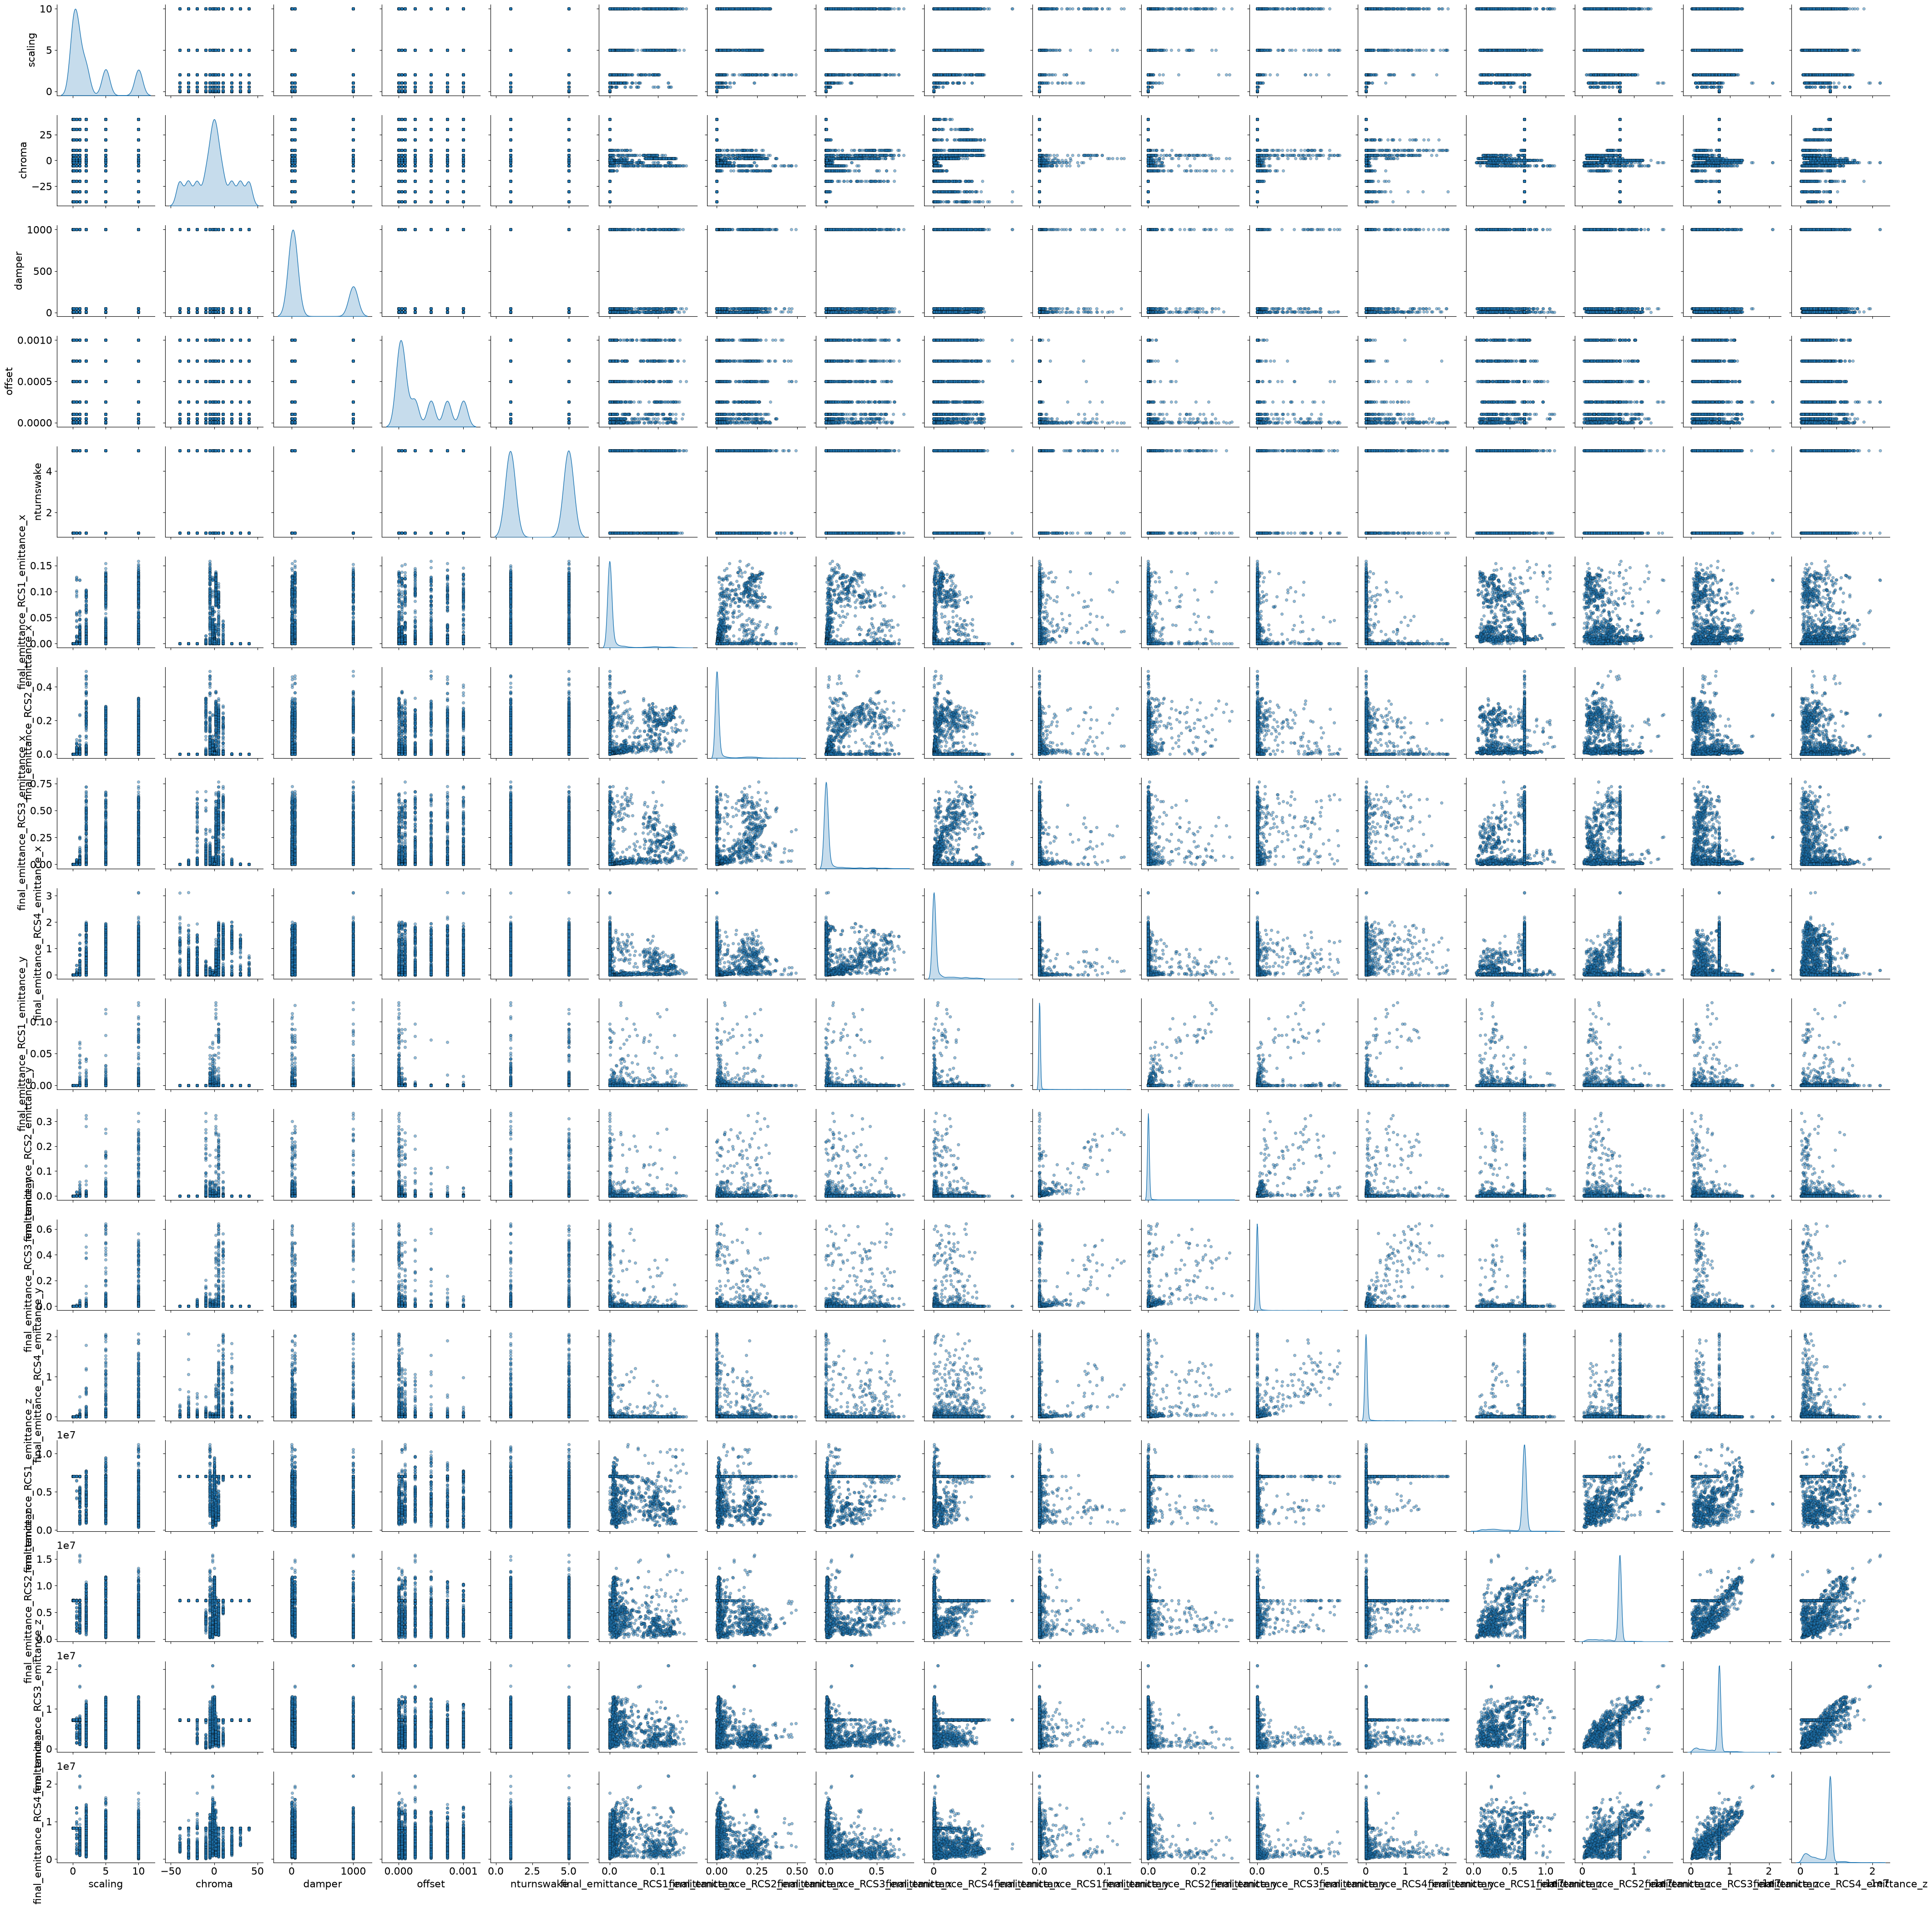

In [15]:
# First a pairplot to see the distribution of the parameters and the final emittance values, and their correlations

sns.pairplot(regrouped_df, vars=parameter_columns + final_emittance_columns,
             diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'k'}, height=2.5)

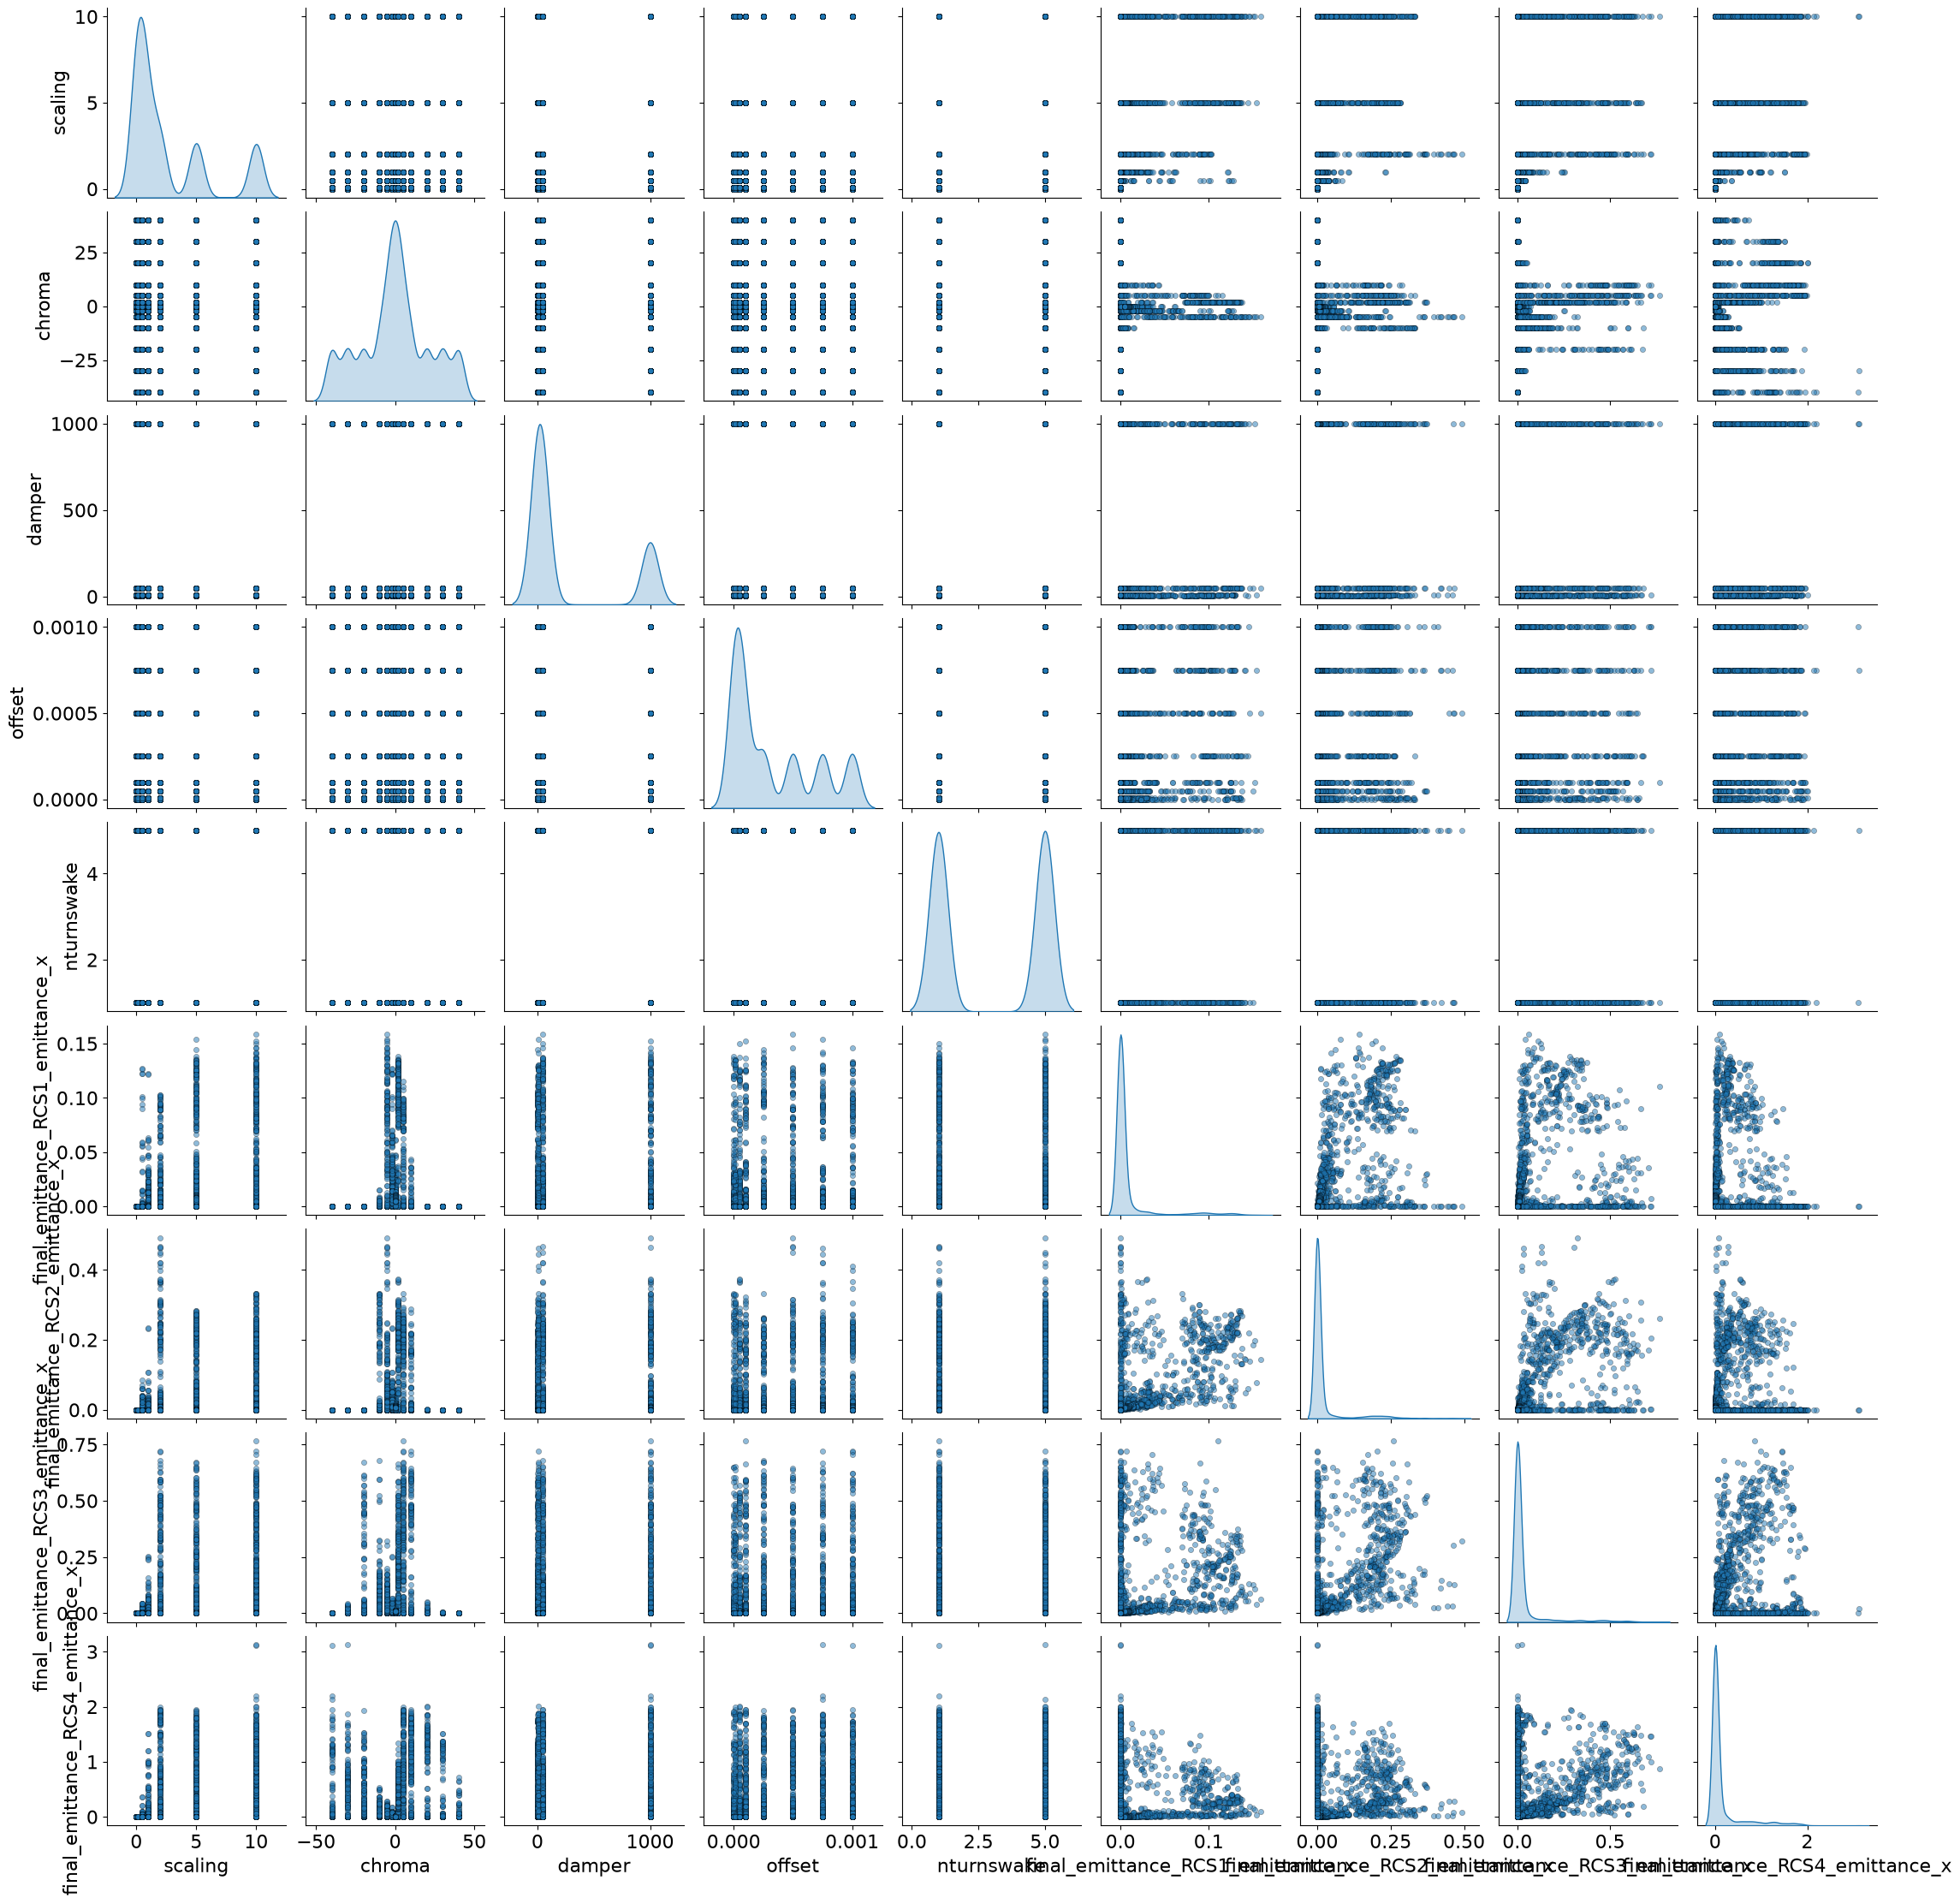

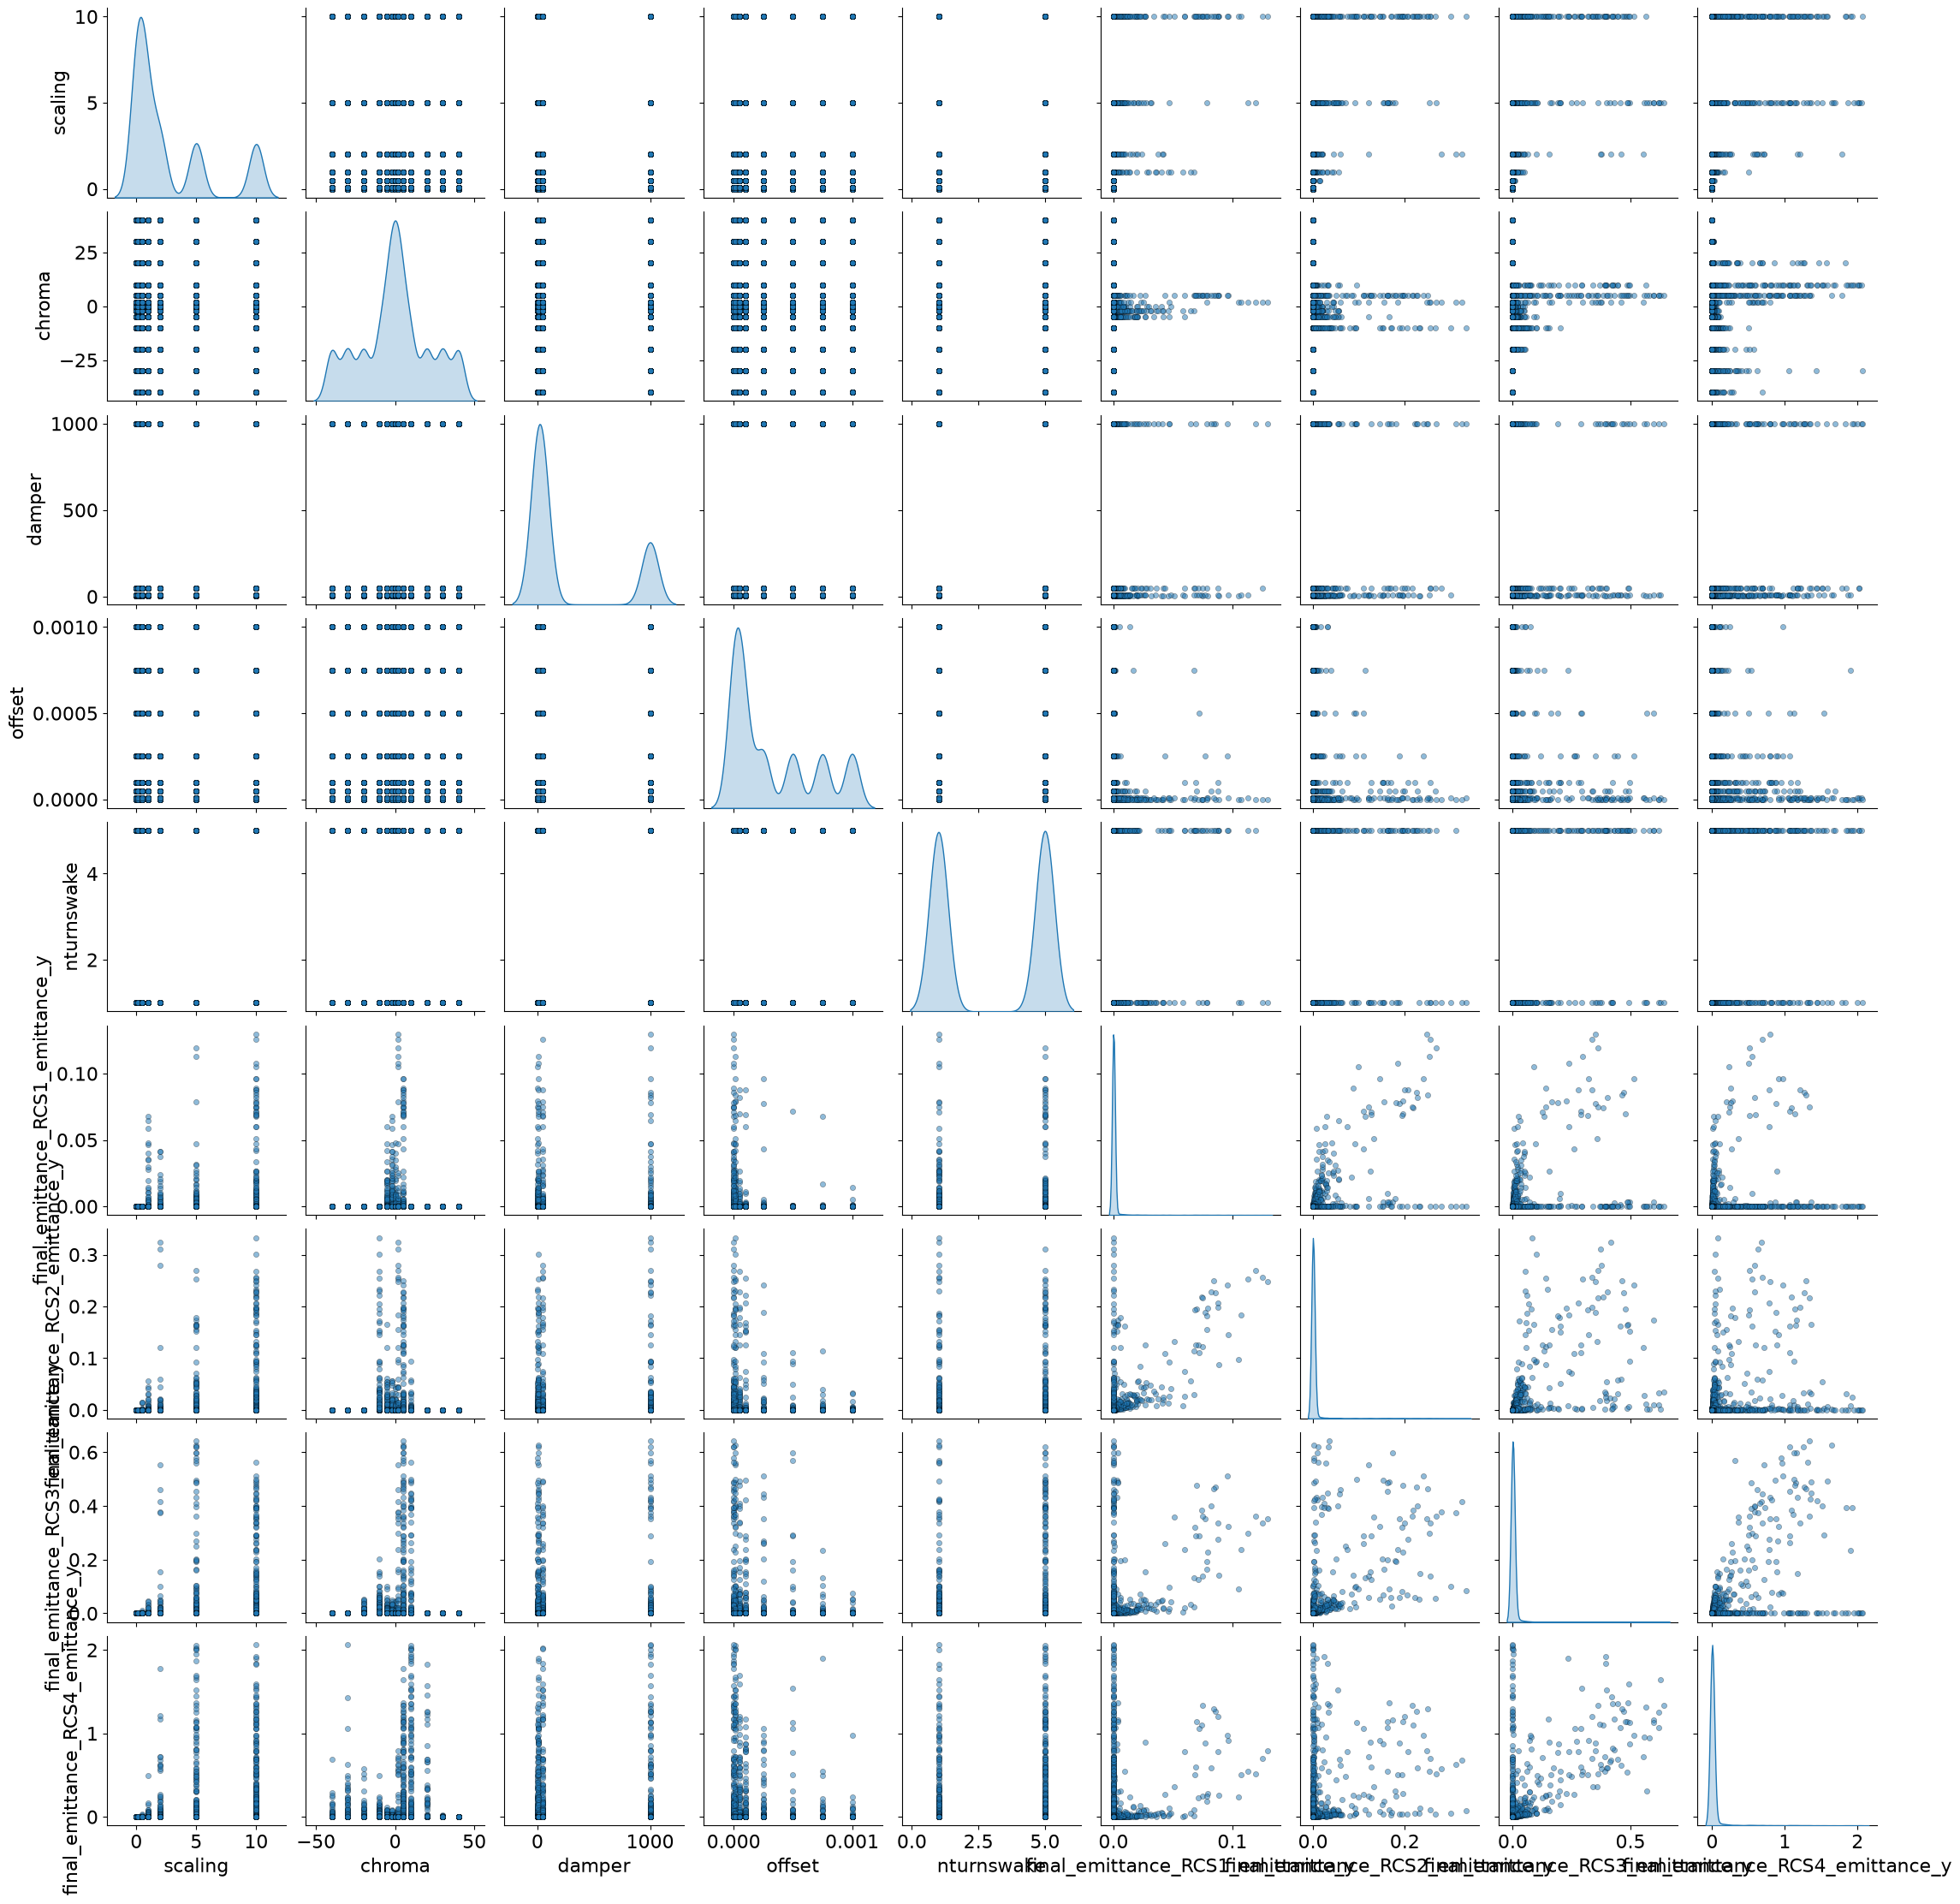

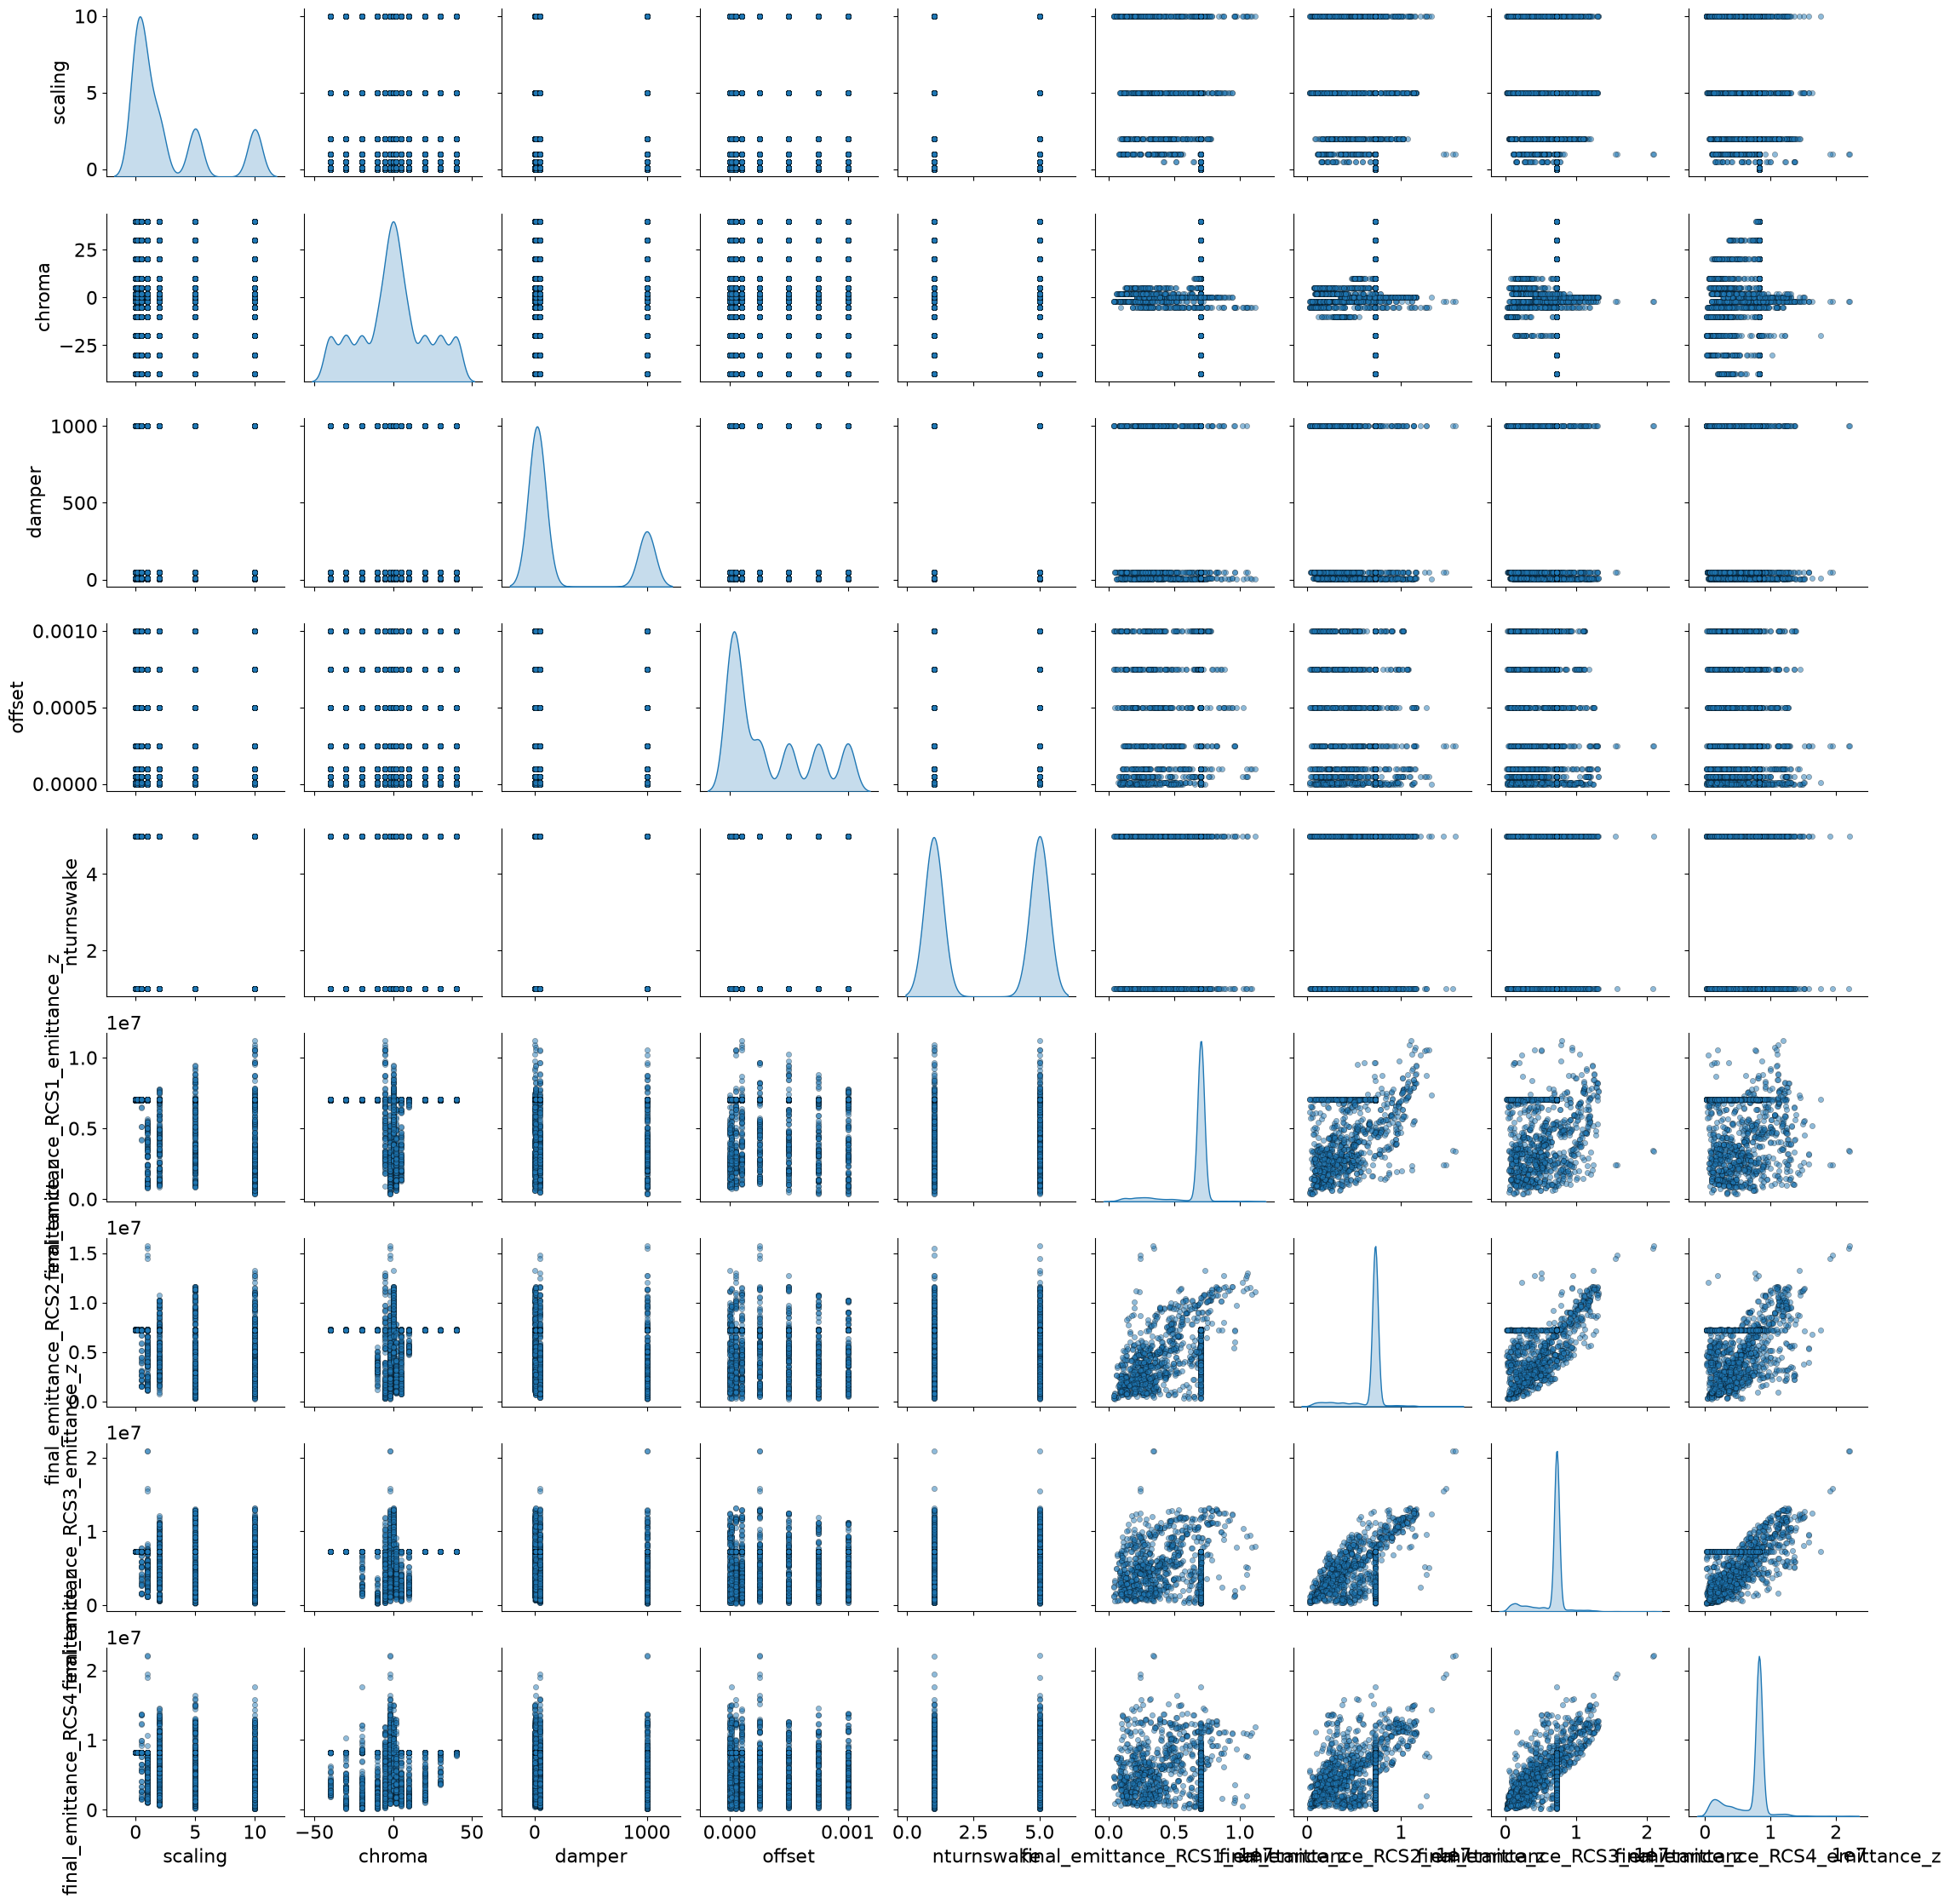

In [16]:
# Too many variables, lets split by plane

for coord in ['x', 'y', 'z']:
    sns.pairplot(regrouped_df,
                 vars=parameter_columns + [f'final_emittance_RCS{i}_emittance_{coord}' for i in range(1, number_of_rcs+1)],
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20, 'edgecolor': 'k'},
                 height=2.5)

Plot the correlation matrix of the regrouped dataframe, for each emittance coordinate (x, y, z) separately. The correlation matrix is computed using the Pearson correlation coefficient.

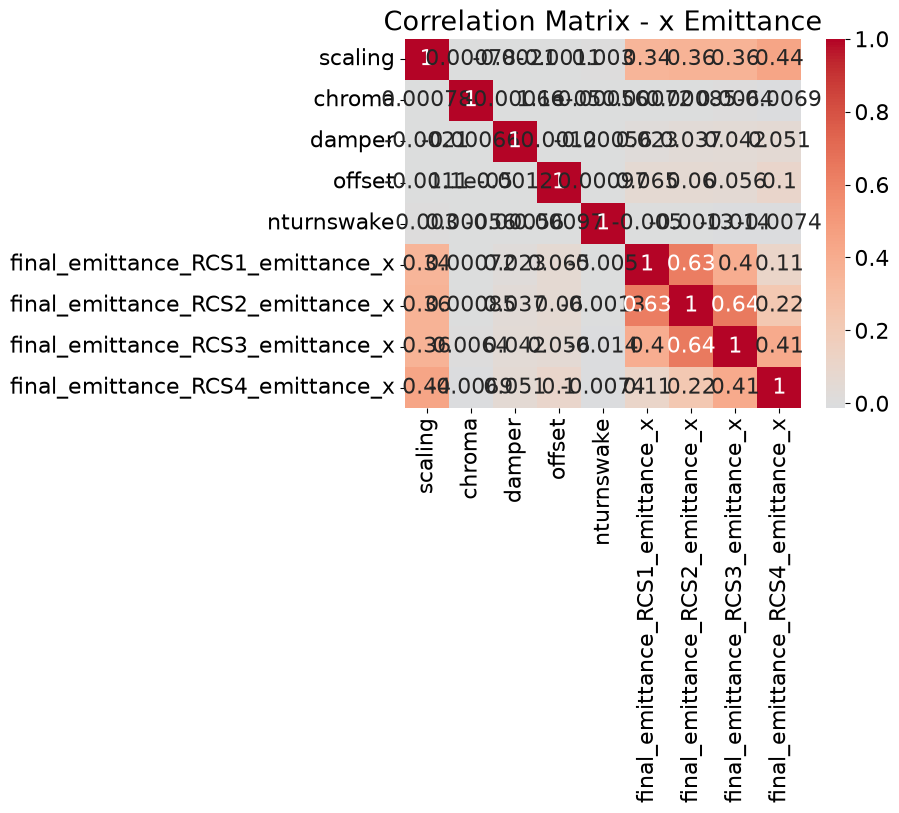

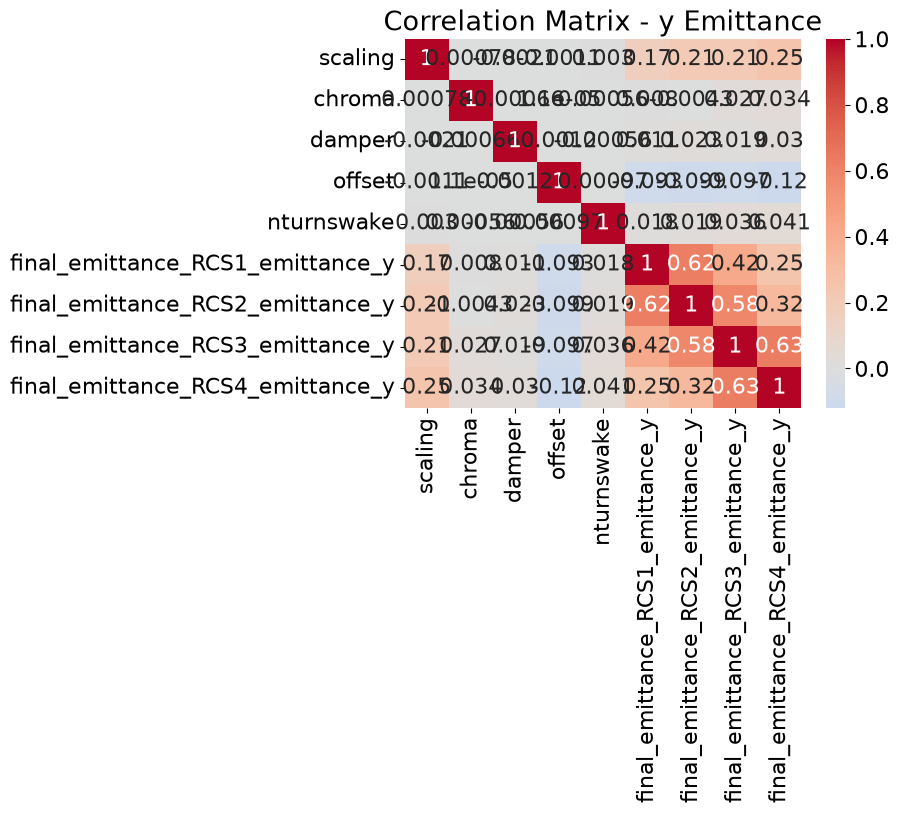

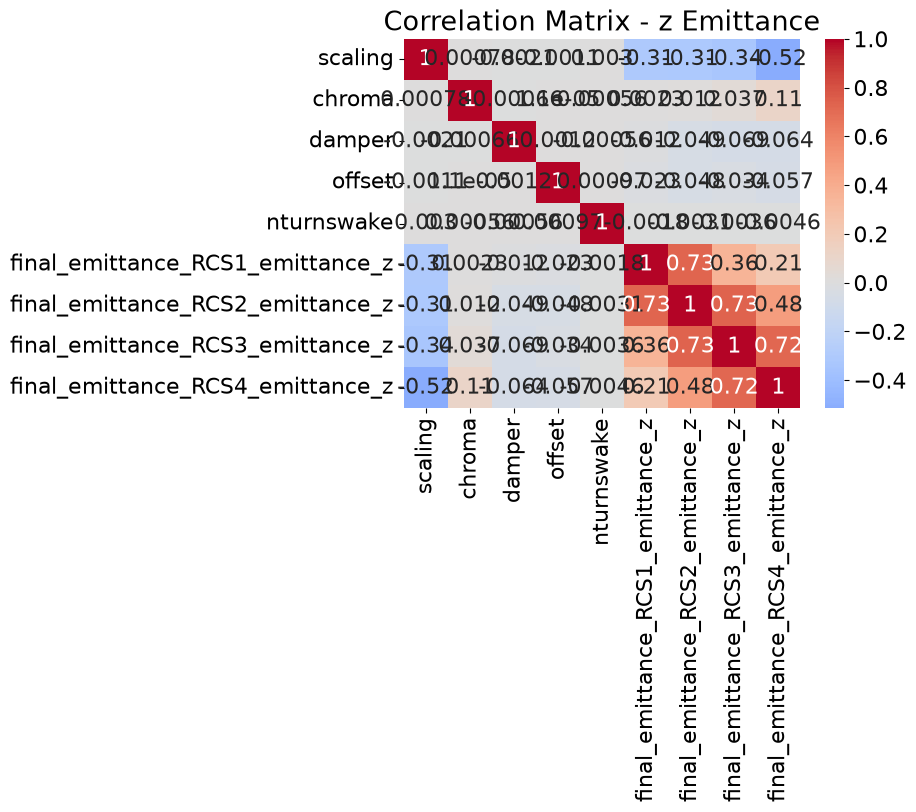

In [17]:

for coord in ['x', 'y', 'z']:
    corr = regrouped_df[parameter_columns + [f'final_emittance_RCS{i}_emittance_{coord}' for i in range(1, number_of_rcs+1)]].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
    plt.title(f'Correlation Matrix - {coord} Emittance')
    plt.show()


## Multi output regression model using the regrouped dataframe and scikit-learn

The goal is to predict the final emittance in each RCS (final_emittance_RCSi_emittance_x, final_emittance_RCSi_emittance_y, final_emittance_RCSi_emittance_z with i=1,2,3,4), given the simulation parameters. We will use a multi output regression model, where the input is the simulation parameters and the output is the final emittance in each RCS.

We will do a train /test split of the regrouped dataframe, then feature scaling, and then train a multi output regression model using scikit-learn. We use `MultiOutputRegressor` wrapper to train a separate regressor for each output.

### Data preparation

The inputs of the surrogate model are the simulation parameters, the outputs are the twelve
final emittances (4 RCS x 3 planes). We keep only the runs for which every parameter and
every emittance is available, then split them into a training and a test set.

In [18]:
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.inspection import permutation_importance

from scipy.stats import loguniform, randint

from IPython.display import display

import time
import warnings
import joblib

# Inputs of the surrogate model: the simulation parameters
feature_columns = parameter_columns

# Outputs of the surrogate model: the final emittance of every RCS, in every plane
target_columns = [f'final_emittance_RCS{i}_emittance_{coord}'
                  for coord in ['x', 'y', 'z']
                  for i in range(1, number_of_rcs + 1)]

# A row with a missing value is a simulation that did not run or did not finish, it cannot
# be learned from, so we drop it.
model_df = regrouped_df[feature_columns + target_columns].dropna(axis=0, how='any')

print(f'{len(regrouped_df) - len(model_df)} runs dropped because of missing values, '
      f'{len(model_df)} runs left')
print(f'{len(feature_columns)} features: {feature_columns}')
print(f'{len(target_columns)} targets: {target_columns}')

X = model_df[feature_columns]
y = model_df[target_columns]

0 runs dropped because of missing values, 5777 runs left
5 features: ['scaling', 'chroma', 'damper', 'offset', 'nturnswake']
12 targets: ['final_emittance_RCS1_emittance_x', 'final_emittance_RCS2_emittance_x', 'final_emittance_RCS3_emittance_x', 'final_emittance_RCS4_emittance_x', 'final_emittance_RCS1_emittance_y', 'final_emittance_RCS2_emittance_y', 'final_emittance_RCS3_emittance_y', 'final_emittance_RCS4_emittance_y', 'final_emittance_RCS1_emittance_z', 'final_emittance_RCS2_emittance_z', 'final_emittance_RCS3_emittance_z', 'final_emittance_RCS4_emittance_z']


In [19]:
# Random split of the runs. The surrogate model is meant to interpolate inside the scanned
# parameter ranges, so a random hold-out is representative of the way it will be used.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'training set: {X_train.shape[0]} runs, test set: {X_test.shape[0]} runs')

training set: 4621 runs, test set: 1156 runs


In [20]:
# The features live on very different scales (offset is of the order of 1e-3 m, damper goes
# up to 1000 turns), so they are standardised. The scaler is fitted on the training set only,
# and it is put inside the model Pipeline further down so that it is refitted on the proper
# subset at every cross-validation split instead of leaking the test/validation statistics.
feature_scaler = StandardScaler().fit(X_train)

display(pd.DataFrame({'mean': feature_scaler.mean_, 'std': feature_scaler.scale_},
                     index=feature_columns))

# The emittances span several orders of magnitude, from the 25 um injected emittance up to a
# few m for the runs that blow up. An absolute error on the raw values would therefore be
# entirely driven by the unstable runs. All the values are strictly positive, so the model is
# trained on log(emittance) and its prediction is exponentiated back to a physical emittance.
print(f'target range: {y.min().min():.3e} to {y.max().max():.3e}')
assert (y > 0).to_numpy().all(), 'the log target transform needs strictly positive emittances'

,mean,std
scaling,2.666241,3.395190
chroma,-0.025536,21.755288
damper,270.798961,427.134754
offset,0.000333,0.000353
nturnswake,2.979658,1.999897


target range: 2.485e-05 to 2.211e+07


### Compute backend: GPU if available, CPU otherwise

scikit-learn is CPU only. The GPU path therefore uses XGBoost, which implements the
scikit-learn estimator API and so plugs unchanged into the `Pipeline` /
`MultiOutputRegressor` / `RandomizedSearchCV` code below. If XGBoost is missing or no usable
CUDA device is found, the model falls back to scikit-learn's own
`HistGradientBoostingRegressor` on the CPU. Everything after this cell is backend agnostic.

In [21]:
def detect_compute_backend():
    """Return (backend_name, xgboost_module_or_None) for the fastest usable backend."""
    try:
        import xgboost
    except ImportError:
        print('xgboost is not installed (pip install xgboost), using scikit-learn on the CPU')
        return 'sklearn-cpu', None

    # The only reliable test is to actually fit something on the GPU. Warnings are promoted to
    # errors during the probe, because XGBoost sometimes only warns before falling back to the
    # CPU by itself, and we want to know about it here rather than be silently slow.
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('error')
            xgboost.XGBRegressor(device='cuda', tree_method='hist', n_estimators=1,
                                 verbosity=0).fit(np.zeros((8, 2)), np.arange(8, dtype=float))
        return 'xgboost-gpu', xgboost
    except Exception as error:
        print(f'no usable GPU ({type(error).__name__}: {error}), using xgboost on the CPU')
        return 'xgboost-cpu', xgboost


backend_name, xgb = detect_compute_backend()
print(f'compute backend: {backend_name}')

xgboost is not installed (pip install xgboost), using scikit-learn on the CPU
compute backend: sklearn-cpu


In [22]:
def make_base_regressor(**overrides):
    """One single-output gradient boosting regressor, on the best available backend."""
    if backend_name.startswith('xgboost'):
        parameters = dict(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1,
            reg_lambda=1.0,
            tree_method='hist',
            device='cuda' if backend_name.endswith('gpu') else 'cpu',
            n_jobs=1 if backend_name.endswith('gpu') else -1,
            random_state=42,
        )
        parameters.update(overrides)
        return xgb.XGBRegressor(**parameters)

    parameters = dict(
        max_iter=600,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.0,
        early_stopping=False,
        random_state=42,
    )
    parameters.update(overrides)
    return HistGradientBoostingRegressor(**parameters)


def build_model(n_jobs_outputs=None, **regressor_overrides):
    """Feature scaling -> one regressor per output -> emittances learned in log space."""
    if n_jobs_outputs is None:
        # A single GPU cannot be shared by several concurrent fits
        n_jobs_outputs = 1 if backend_name.endswith('gpu') else 8

    return Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', TransformedTargetRegressor(
            regressor=MultiOutputRegressor(make_base_regressor(**regressor_overrides),
                                           n_jobs=n_jobs_outputs),
            func=np.log,
            inverse_func=np.exp,
        )),
    ])


# Prefix needed to reach the parameters of the individual regressors through the three
# wrappers (Pipeline -> TransformedTargetRegressor -> MultiOutputRegressor)
parameter_prefix = 'regressor__regressor__estimator__'

build_model()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",MultiOutputRe... n_jobs=8)
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'exp'>
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None


### Baseline multi-output model

`MultiOutputRegressor` fits one independent regressor per emittance column, so the twelve
outputs are predicted by twelve models sharing the same architecture and preprocessing.

In [23]:
baseline_model = build_model()

start_time = time.perf_counter()
baseline_model.fit(X_train, y_train)

print(f'trained {len(target_columns)} regressors on {backend_name} '
      f'in {time.perf_counter() - start_time:.1f} s')

trained 12 regressors on sklearn-cpu in 4.4 s


In [24]:
def evaluate_model(model, X_data, y_data):
    """Per-target quality of the surrogate model. Returns (metrics table, predictions)."""
    predictions = pd.DataFrame(model.predict(X_data), index=y_data.index, columns=y_data.columns)

    metrics = []
    for column in y_data.columns:
        true_values = y_data[column]
        predicted_values = predictions[column].clip(lower=1e-30)

        metrics.append({
            'target': column,
            # R2 on the physical emittances: dominated by the large, unstable cases
            'R2': r2_score(true_values, predicted_values),
            # R2 in log space: how well the model does over the whole dynamic range
            'R2_log': r2_score(np.log10(true_values), np.log10(predicted_values)),
            'RMSE': root_mean_squared_error(true_values, predicted_values),
            'median_relative_error_%': 100 * np.median(
                np.abs(predicted_values - true_values) / true_values),
        })

    return pd.DataFrame(metrics).set_index('target'), predictions


baseline_train_metrics, _ = evaluate_model(baseline_model, X_train, y_train)
baseline_test_metrics, baseline_test_predictions = evaluate_model(baseline_model, X_test, y_test)

print('training set')
display(baseline_train_metrics)
print('test set')
display(baseline_test_metrics)

training set


,R2,R2_log,RMSE,median_relative_error_%
target,,,,
final_emittance_RCS1_emittance_x,0.916101,0.994852,0.007036,1.618666
final_emittance_RCS2_emittance_x,0.902127,0.992872,0.018348,3.058184
final_emittance_RCS3_emittance_x,0.879299,0.991588,0.037167,5.114804
final_emittance_RCS4_emittance_x,0.852007,0.989501,0.149151,10.085469
final_emittance_RCS1_emittance_y,0.648462,0.945477,0.004287,1.532273
final_emittance_RCS2_emittance_y,0.595117,0.946571,0.013117,2.664737
final_emittance_RCS3_emittance_y,0.623076,0.953633,0.030237,3.447146
final_emittance_RCS4_emittance_y,0.590916,0.951778,0.108854,5.861992
final_emittance_RCS1_emittance_z,0.968551,0.971800,254734.915870,0.362021


test set


,R2,R2_log,RMSE,median_relative_error_%
target,,,,
final_emittance_RCS1_emittance_x,0.830108,0.988480,1.013851e-02,1.679581
final_emittance_RCS2_emittance_x,0.867343,0.988682,2.164117e-02,3.463745
final_emittance_RCS3_emittance_x,0.820846,0.982479,4.414811e-02,5.589573
final_emittance_RCS4_emittance_x,0.688711,0.978299,2.025201e-01,11.804525
final_emittance_RCS1_emittance_y,0.407207,0.864869,4.290812e-03,1.556948
final_emittance_RCS2_emittance_y,0.518596,0.888028,1.443376e-02,2.786894
final_emittance_RCS3_emittance_y,-0.349962,0.894376,4.394614e-02,3.871988
final_emittance_RCS4_emittance_y,-0.296401,0.909166,1.711393e-01,6.932049
final_emittance_RCS1_emittance_z,0.956902,0.943784,3.166767e+05,0.372910


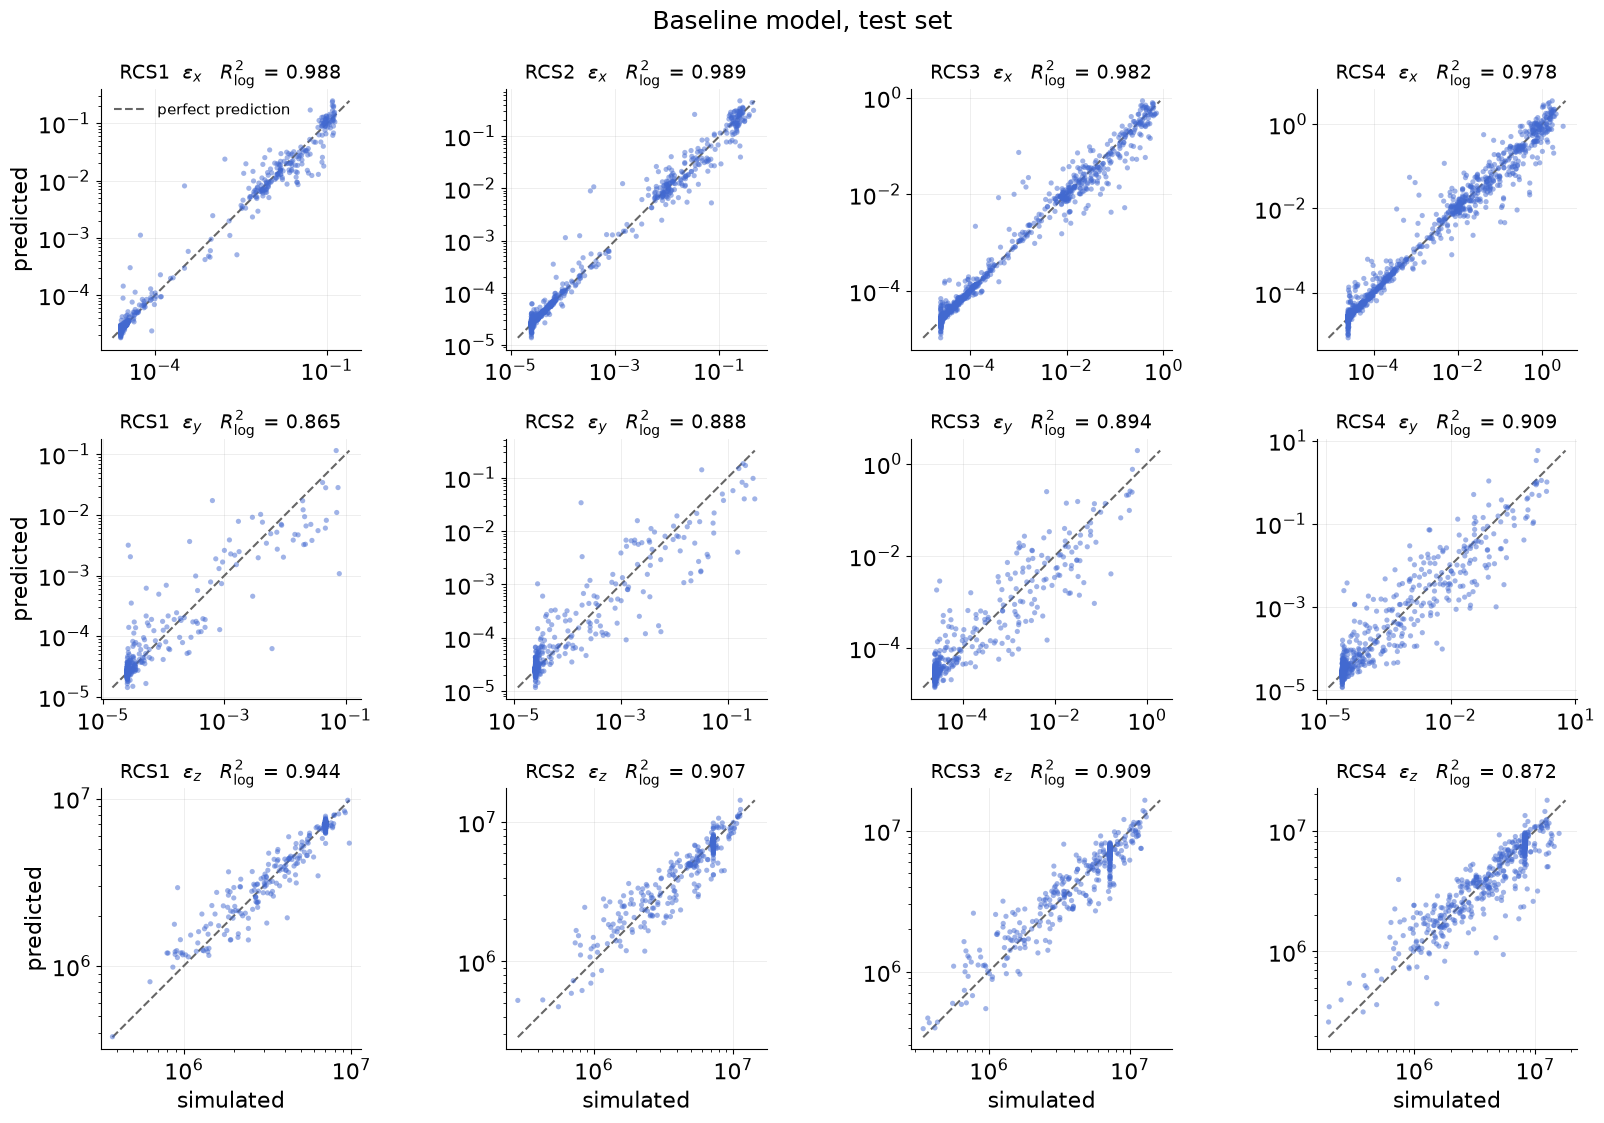

In [25]:
def plot_parity(y_true, y_pred, title):
    """Predicted against simulated emittance, one panel per RCS and plane."""
    figure, axes = plt.subplots(3, number_of_rcs, figsize=(4.2 * number_of_rcs, 11.5))

    for row, coord in enumerate(['x', 'y', 'z']):
        for column_index in range(number_of_rcs):
            column = f'final_emittance_RCS{column_index + 1}_emittance_{coord}'
            axis = axes[row, column_index]

            true_values = y_true[column]
            predicted_values = y_pred[column].clip(lower=1e-30)

            limits = [min(true_values.min(), predicted_values.min()),
                      max(true_values.max(), predicted_values.max())]

            axis.plot(limits, limits, color='0.4', linewidth=1.5, linestyle='--',
                      label='perfect prediction', zorder=1)
            axis.scatter(true_values, predicted_values, s=14, alpha=0.5, color='#4269D0',
                         edgecolor='none', zorder=2)

            axis.set_xscale('log')
            axis.set_yscale('log')
            axis.set_aspect('equal', adjustable='box')
            axis.grid(True, which='major', alpha=0.3, linewidth=0.5)
            axis.set_axisbelow(True)
            for spine in ('top', 'right'):
                axis.spines[spine].set_visible(False)

            axis.set_title(f'RCS{column_index + 1}  $\\epsilon_{coord}$   '
                           f'$R^2_{{\\log}}$ = {r2_score(np.log10(true_values), np.log10(predicted_values)):.3f}',
                           fontsize=14)
            if column_index == 0:
                axis.set_ylabel('predicted')
            if row == 2:
                axis.set_xlabel('simulated')

    axes[0, 0].legend(fontsize=11, frameon=False, loc='upper left')
    figure.suptitle(title, fontsize=18)
    figure.tight_layout()
    plt.show()


plot_parity(y_test, baseline_test_predictions, 'Baseline model, test set')

### Hyperparameter scan

The scan is run with `RandomizedSearchCV`: it samples configurations from the distributions
below, scores each of them by 5-fold cross-validation *on the training set only* (uniform
average of the R2 of the twelve outputs), and refits the best one on the whole training set.
The test set stays untouched until the very end.

Switch `RandomizedSearchCV` for `GridSearchCV` with explicit value lists if an exhaustive
scan of a smaller space is preferred, the rest of the cell is identical.

In [26]:
if backend_name.startswith('xgboost'):
    parameter_distributions = {
        parameter_prefix + 'n_estimators': randint(200, 1200),
        parameter_prefix + 'max_depth': randint(3, 12),
        parameter_prefix + 'learning_rate': loguniform(0.01, 0.3),
        parameter_prefix + 'subsample': [0.6, 0.8, 1.0],
        parameter_prefix + 'colsample_bytree': [0.6, 0.8, 1.0],
        parameter_prefix + 'min_child_weight': randint(1, 10),
        parameter_prefix + 'reg_lambda': loguniform(1e-2, 10.0),
    }
else:
    parameter_distributions = {
        parameter_prefix + 'max_iter': randint(200, 1200),
        parameter_prefix + 'learning_rate': loguniform(0.01, 0.3),
        parameter_prefix + 'max_leaf_nodes': randint(15, 128),
        parameter_prefix + 'min_samples_leaf': randint(5, 60),
        parameter_prefix + 'l2_regularization': loguniform(1e-4, 10.0),
        parameter_prefix + 'max_features': [0.6, 0.8, 1.0],
    }

# Raise this for a finer scan, it is the number of parameter sets that are tried
number_of_candidates = 100

# The twelve single-output regressors are fitted one after the other inside each candidate and
# the candidates themselves are spread over the CPU cores. On a GPU there is a single device,
# so the candidates are run one at a time instead.
search_n_jobs = 1 if backend_name.endswith('gpu') else -1

hyperparameter_search = RandomizedSearchCV(
    estimator=build_model(n_jobs_outputs=1),
    param_distributions=parameter_distributions,
    n_iter=number_of_candidates,
    scoring='r2',
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=search_n_jobs,
    refit=True,
    random_state=42,
    return_train_score=True,
    verbose=1,
)

start_time = time.perf_counter()
hyperparameter_search.fit(X_train, y_train)

print(f'scanned {number_of_candidates} configurations in '
      f'{(time.perf_counter() - start_time) / 60:.1f} min')
print(f'best cross-validated R2: {hyperparameter_search.best_score_:.4f}')
print('best parameters:')
for name, value in sorted(hyperparameter_search.best_params_.items()):
    print(f'  {name.replace(parameter_prefix, "")}: {value}')

Fitting 5 folds for each of 100 candidates, totalling 500 fits
scanned 100 configurations in 26.7 min
best cross-validated R2: 0.7102
best parameters:
  l2_regularization: 5.179261664176366
  learning_rate: 0.07666495926746603
  max_features: 1.0
  max_iter: 285
  max_leaf_nodes: 42
  min_samples_leaf: 6


In [27]:
# The ten best configurations of the scan. A mean_train_score much higher than the
# mean_test_score is the signature of a configuration that overfits the training runs.
search_results = pd.DataFrame(hyperparameter_search.cv_results_)

scanned_parameter_columns = [column for column in search_results.columns
                             if column.startswith('param_')]

search_results_summary = search_results[
    ['mean_test_score', 'std_test_score', 'mean_train_score', 'mean_fit_time']
    + scanned_parameter_columns
].rename(columns={column: column.replace('param_' + parameter_prefix, '')
                  for column in scanned_parameter_columns})

display(search_results_summary.sort_values('mean_test_score', ascending=False).head(10))

,mean_test_score,std_test_score,mean_train_score,mean_fit_time,l2_regularization,learning_rate,max_features,max_iter,max_leaf_nodes,min_samples_leaf
25,0.710162,0.030664,0.868392,10.246283,5.179262,0.076665,1.0,285,42,6
36,0.703925,0.029623,0.817070,16.200256,0.642833,0.022440,1.0,493,38,9
16,0.700395,0.026054,0.801476,24.595463,0.726480,0.019657,1.0,338,95,12
38,0.695042,0.047751,0.921071,69.061847,1.501456,0.029774,0.8,663,107,7
29,0.694001,0.025393,0.826760,27.715484,0.005792,0.028197,0.8,655,41,13
71,0.663560,0.024781,0.760070,24.792490,0.001796,0.018719,0.8,990,23,16
34,0.663334,0.028224,0.751055,21.403940,0.011355,0.011190,0.6,584,33,6
7,0.652185,0.053215,0.865832,55.916721,0.252080,0.046285,0.8,587,103,18
13,0.646556,0.054577,0.858096,45.348620,0.071157,0.058794,0.8,495,99,20
65,0.641290,0.035582,0.799571,55.166883,0.229156,0.030530,0.8,774,76,26


In [28]:
# Final quality of the tuned model, on the test set that was never used during the scan
tuned_model = hyperparameter_search.best_estimator_
tuned_test_metrics, tuned_test_predictions = evaluate_model(tuned_model, X_test, y_test)

metrics_comparison = pd.DataFrame({
    'R2_log baseline': baseline_test_metrics['R2_log'],
    'R2_log tuned': tuned_test_metrics['R2_log'],
    'median rel. error % baseline': baseline_test_metrics['median_relative_error_%'],
    'median rel. error % tuned': tuned_test_metrics['median_relative_error_%'],
})

display(metrics_comparison)

,R2_log baseline,R2_log tuned,median rel. error % baseline,median rel. error % tuned
target,,,,
final_emittance_RCS1_emittance_x,0.988480,0.991342,1.679581,0.744355
final_emittance_RCS2_emittance_x,0.988682,0.990868,3.463745,2.194864
final_emittance_RCS3_emittance_x,0.982479,0.985592,5.589573,4.688508
final_emittance_RCS4_emittance_x,0.978299,0.981105,11.804525,10.412090
final_emittance_RCS1_emittance_y,0.864869,0.864799,1.556948,0.578124
final_emittance_RCS2_emittance_y,0.888028,0.888431,2.786894,0.951478
final_emittance_RCS3_emittance_y,0.894376,0.896096,3.871988,1.625644
final_emittance_RCS4_emittance_y,0.909166,0.913431,6.932049,3.132891
final_emittance_RCS1_emittance_z,0.943784,0.953659,0.372910,0.165660


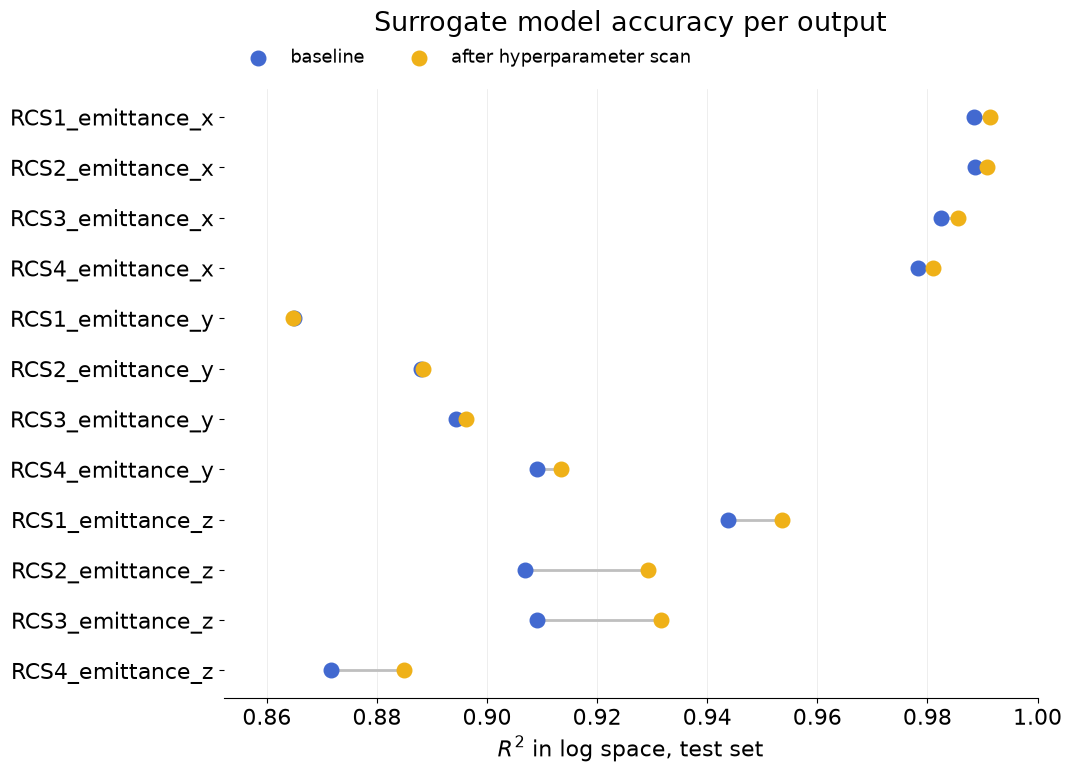

In [29]:
# Per-target comparison of the two models on the test set. The two scores are usually both
# close to 1, so they are shown as positions on a zoomed axis rather than as bar lengths,
# which would need a misleading truncated baseline to be readable.
figure, axis = plt.subplots(figsize=(11, 8))

target_positions = np.arange(len(target_columns))
baseline_scores = metrics_comparison['R2_log baseline'].to_numpy()
tuned_scores = metrics_comparison['R2_log tuned'].to_numpy()

axis.hlines(target_positions, baseline_scores, tuned_scores, color='0.75', linewidth=2,
            zorder=1)
axis.scatter(baseline_scores, target_positions, s=110, color='#4269D0', zorder=2,
             label='baseline')
axis.scatter(tuned_scores, target_positions, s=110, color='#EFB118', zorder=3,
             label='after hyperparameter scan')

axis.set_yticks(target_positions)
axis.set_yticklabels([name.replace('final_emittance_', '') for name in target_columns])
axis.invert_yaxis()
axis.set_xlabel('$R^2$ in log space, test set')

score_range = np.concatenate([baseline_scores, tuned_scores])
margin = max(0.005, 0.1 * (score_range.max() - score_range.min()))
axis.set_xlim(score_range.min() - margin, min(1.0, score_range.max() + margin))

axis.grid(True, axis='x', alpha=0.3, linewidth=0.5)
axis.set_axisbelow(True)
for spine in ('top', 'right', 'left'):
    axis.spines[spine].set_visible(False)
axis.legend(frameon=False, fontsize=13, ncol=2, loc='lower left',
            bbox_to_anchor=(0.0, 1.01))
axis.set_title('Surrogate model accuracy per output', pad=42)

figure.tight_layout()
plt.show()

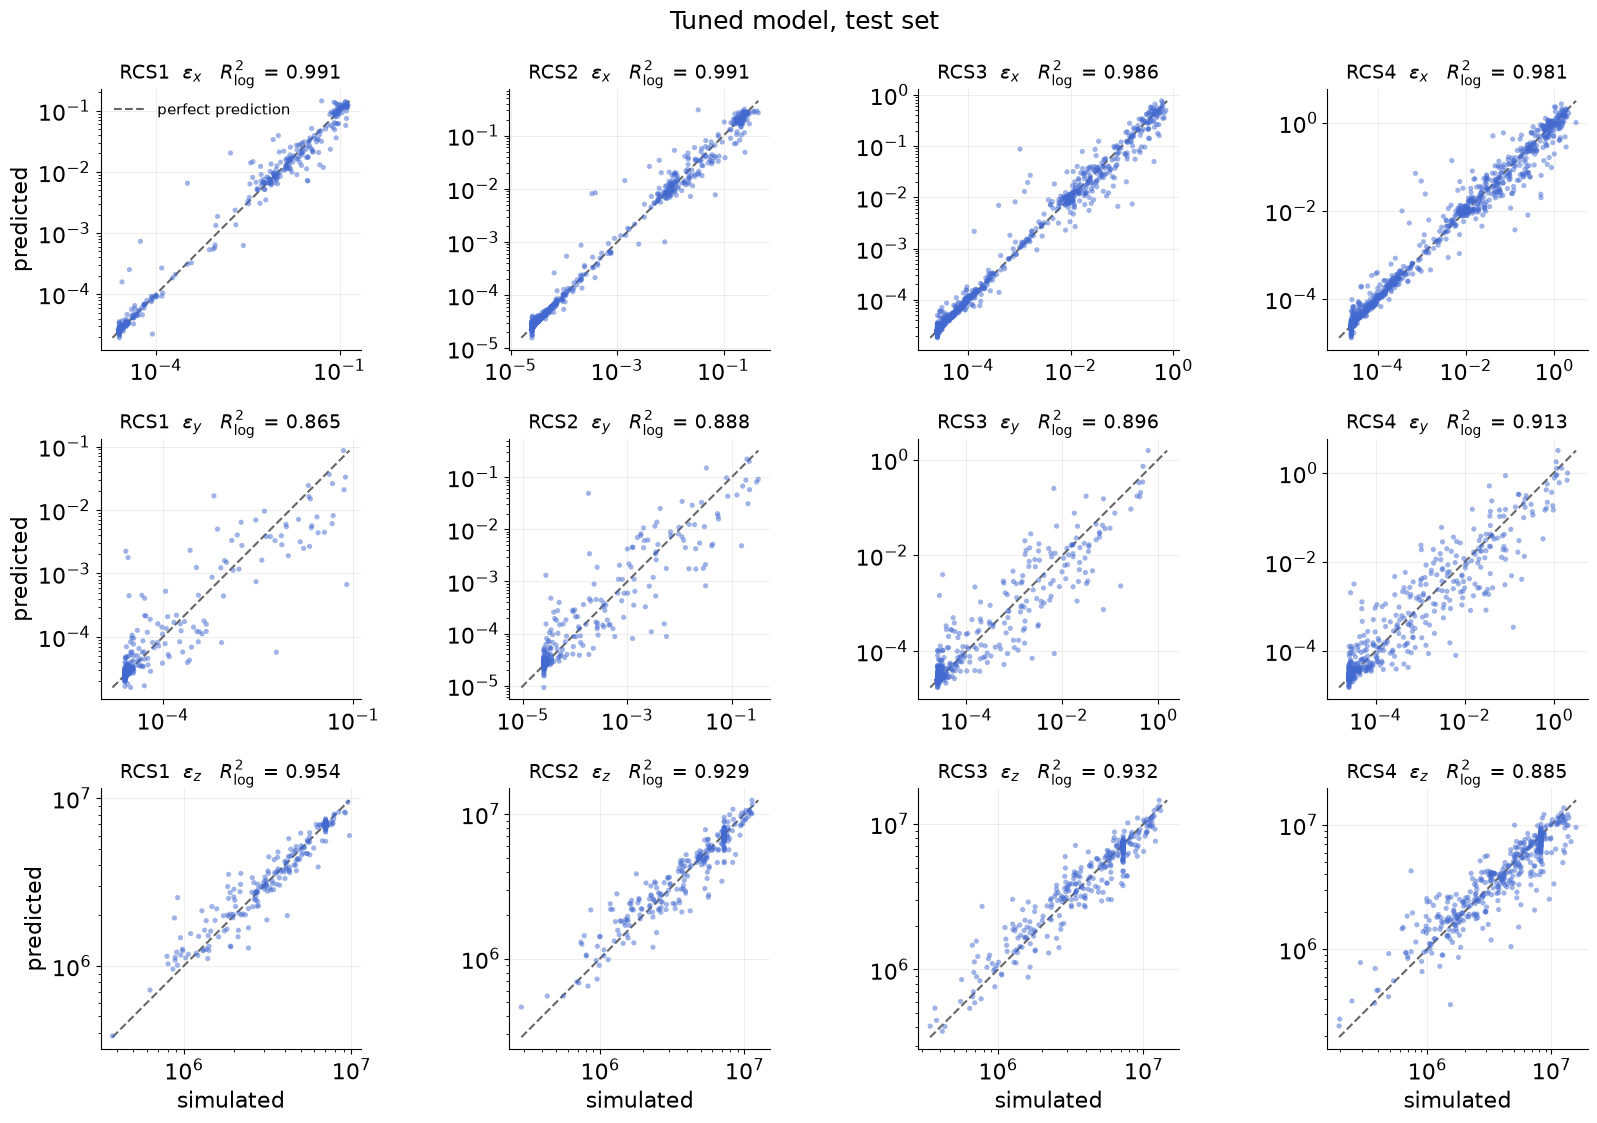

In [30]:
plot_parity(y_test, tuned_test_predictions, 'Tuned model, test set')

In [31]:
# Which simulation parameters actually drive the final emittances. Permutation importance is
# measured on the test set, so it reflects what the model relies on to generalise.
importance = permutation_importance(tuned_model, X_test, y_test, scoring='r2',
                                    n_repeats=10, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'mean_R2_drop': importance.importances_mean,
    'std': importance.importances_std,
}, index=feature_columns).sort_values('mean_R2_drop', ascending=False)

display(importance_df)

,mean_R2_drop,std
chroma,1.253772,0.037963
scaling,1.216710,0.090584
offset,0.396494,0.084629
damper,0.056641,0.025967
nturnswake,0.054387,0.037820


### Export for the web interface

Everything the Dash application needs is written in a single file: the tuned model, the
reference emittances it compares its predictions to, the training and test runs, and the
quality metrics shown on the expert page. Datasets are stored as plain arrays so that the
file only depends on the scikit-learn version, not on the pandas one.

In [34]:
from datetime import date

# A run without wakefield and without injection offset has neither an instability nor a
# decoherence to blow up its emittance, so it gives the emittance the beam keeps at the exit of
# each RCS. This is the reference the web interface compares a prediction to when it decides
# whether a beam is stable.
undisturbed_runs = model_df[(model_df['scaling'] == 0.0) & (model_df['offset'] == 0.0)]
reference_emittance = undisturbed_runs[target_columns].median()

print(f'reference emittances computed on {len(undisturbed_runs)} undisturbed runs')
display(reference_emittance)

surrogate_bundle = {
    'model': tuned_model,
    'feature_columns': feature_columns,
    'target_columns': target_columns,
    'number_of_rcs': number_of_rcs,
    'reference_emittance': reference_emittance.to_numpy(),
    'train_features': X_train.to_numpy(),
    'train_targets': y_train.to_numpy(),
    'test_features': X_test.to_numpy(),
    'test_targets': y_test.to_numpy(),
    'test_predictions': tuned_test_predictions.to_numpy(),
    'test_metrics': tuned_test_metrics.to_dict(orient='index'),
    'best_parameters': {name.replace(parameter_prefix, ''): value
                        for name, value in hyperparameter_search.best_params_.items()},
    'cross_validated_r2': hyperparameter_search.best_score_,
    'regressor_class': type(make_base_regressor()).__name__,
    'training_backend': backend_name,
    'simulation_dataset': folder_name[0],
    'export_date': date.today().isoformat(),
}

bundle_file = Path('model/surrogate_bundle.joblib')
bundle_file.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(surrogate_bundle, bundle_file, compress=3)

print(f'bundle written to {bundle_file.resolve()} '
      f'({bundle_file.stat().st_size / 1e6:.1f} MB)')

reference emittances computed on 104 undisturbed runs


final_emittance_RCS1_emittance_x    2.500165e-05
final_emittance_RCS2_emittance_x    2.500157e-05
final_emittance_RCS3_emittance_x    2.500152e-05
final_emittance_RCS4_emittance_x    2.500151e-05
final_emittance_RCS1_emittance_y    2.499860e-05
final_emittance_RCS2_emittance_y    2.499843e-05
final_emittance_RCS3_emittance_y    2.499822e-05
final_emittance_RCS4_emittance_y    2.499818e-05
final_emittance_RCS1_emittance_z    7.030484e+06
final_emittance_RCS2_emittance_z    7.242071e+06
final_emittance_RCS3_emittance_z    7.250139e+06
final_emittance_RCS4_emittance_z    8.247142e+06
dtype: float64

bundle written to /home/damorim/WorkDrive/Trainings/surrogate-model-rcs/rcs-stability-surrogate-model/model/surrogate_bundle.joblib (6.5 MB)


In [35]:
def predict_final_emittances(**parameters):
    """Predict the twelve final emittances for one set of simulation parameters.

    Example: predict_final_emittances(scaling=1.0, chroma=-10, damper=10, offset=250e-6,
                                      nturnswake=5)
    """
    query = pd.DataFrame([[parameters[name] for name in feature_columns]], columns=feature_columns)
    return pd.Series(tuned_model.predict(query)[0], index=target_columns)


start_time = time.perf_counter()
example_prediction = predict_final_emittances(scaling=1.0, chroma=-10, damper=10,
                                              offset=250e-6, nturnswake=5)
print(f'prediction obtained in {1e3 * (time.perf_counter() - start_time):.1f} ms')
display(example_prediction)

prediction obtained in 42.8 ms


final_emittance_RCS1_emittance_x    2.457662e-05
final_emittance_RCS2_emittance_x    2.612712e-05
final_emittance_RCS3_emittance_x    1.535149e-04
final_emittance_RCS4_emittance_x    2.389565e-02
final_emittance_RCS1_emittance_y    2.488972e-05
final_emittance_RCS2_emittance_y    2.500657e-05
final_emittance_RCS3_emittance_y    2.581850e-05
final_emittance_RCS4_emittance_y    4.413838e-05
final_emittance_RCS1_emittance_z    6.991979e+06
final_emittance_RCS2_emittance_z    7.212118e+06
final_emittance_RCS3_emittance_z    7.236501e+06
final_emittance_RCS4_emittance_z    5.481175e+06
dtype: float64